# MicroBooNe open samples for Neutrino Vertices

Before running this please toy around with the Open Samples repository AND the tutorials beforehand. May also quire using 'more' statistics (i.e. using the full withWire Open samples data. Though if you do, expect it to be both: demanding on storage AND computational power so if too heavy don't run this locally.)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras # Download modern tensorflow on the ubopendata environment

## Remove empty events

First we will be plotting the total sum of all pixel intensity / summed ADC values for each recorded segment in the inputData. The goal is to gauge the overall quantity of tracks such that we remove segments that contain no tracks or minimal pixels. We have a few ways of considering them and we plan on using various methods for validation (i.e. Considering truth level information, binary classification).

To make the new non-empty images, we will be following the procedure from the tutorial with a few additional procedures. After slicing our wireplane into their respective image cuts, we will then remove any segments without any tracks using the total number of charge collected. 

**Note**: This will require using much heavier statistics given that we are removing roughly 40% - 90% of the total images so instead of using just one bnb_WithWire file (in our tutorial studies we used `bnb_WithWire_00.h5`) it may be recommended to use anywhere from 4 - 5 wire data files or even all 18 from: https://zenodo.org/records/7262009. 

You can do this by running `plane_2.py` which will convert the with wire data files into their plane 2.

Then run `tile_stats.py` 

### Histogram of all summed charge values for each "tile"

In [4]:
import h5py
from pathlib import Path

# Per-tile summed charge comes straight from the tile catalogs written by
# tile_stats.py (one `_tilestats.h5` per wire file). Those already hold the
# summed charge of every tile AFTER the noise cutoff (10) and saturation
# clip (100), for all three tile sizes -- so no image data is re-read here.

PROC_DIR = Path("../../data/ubopendata/processed_npy")
if not PROC_DIR.exists():                       # if the kernel's cwd is the repo root
    PROC_DIR = Path("data/ubopendata/processed_npy")

SIZES = [(18, 16), (64, 32), (864, 64)]
FILES = range(18)                               # all 18 bnb_WithWire files
CHARGE_MIN = 50                                 # candidate emptiness cut
SATURATION = 100

# Log-spaced bins per tile size. The smallest possible non-zero charge is one
# pixel at the 10-ADC cutoff; the largest is every pixel saturated at 100.
BINS = {s: np.logspace(np.log10(10.0), np.log10(s[0] * s[1] * SATURATION), 81)
        for s in SIZES}

# Accumulate counts file-by-file: the 18x16 catalog alone holds ~187M tiles,
# so we never hold them all in memory at once.
counts = {s: np.zeros(len(BINS[s]) - 1, dtype=np.int64) for s in SIZES}
n_tiles = {s: 0 for s in SIZES}
n_empty = {s: 0 for s in SIZES}
max_charge = {s: 0.0 for s in SIZES}

for f in FILES:
    with h5py.File(str(PROC_DIR / ("bnb_WithWire_%02d_tilestats.h5" % f)), "r") as h:
        for s in SIZES:
            c = h["%dx%d" % s]["charge"][:].reshape(-1)
            n_tiles[s] += c.size
            n_empty[s] += int(np.count_nonzero(c == 0))
            max_charge[s] = max(max_charge[s], float(c.max()) if c.size else 0.0)
            counts[s] += np.histogram(c[c > 0], bins=BINS[s])[0]   # zeros can't sit on a log axis
            del c

print("%-9s %14s %10s %10s %12s" % ("tile", "tiles", "empty%", ">=50%", "max charge"))
print("-" * 60)
for s in SIZES:
    frac50 = 100.0 * counts[s][BINS[s][:-1] >= CHARGE_MIN].sum() / n_tiles[s]
    print("%-9s %14d %9.2f%% %9.2f%% %12.0f"
          % ("%dx%d" % s, n_tiles[s], 100.0 * n_empty[s] / n_tiles[s],
             frac50, max_charge[s]))

tile               tiles     empty%      >=50%   max charge
------------------------------------------------------------
18x16          186869760     94.65%      4.73%        28800
64x32           26278560     83.43%     14.44%       197029
864x64            973280      8.96%     86.19%      1058251


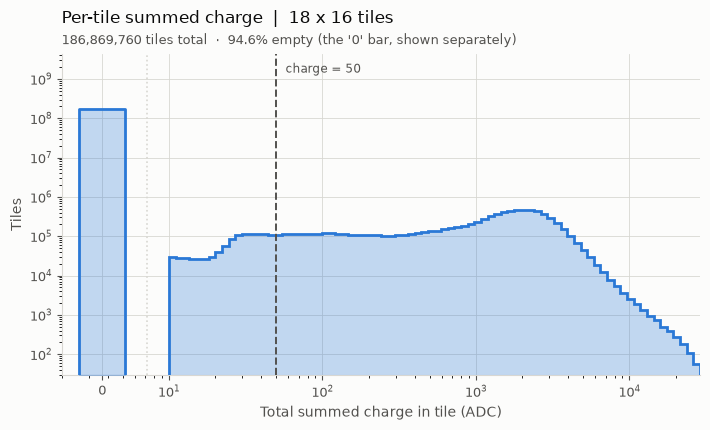

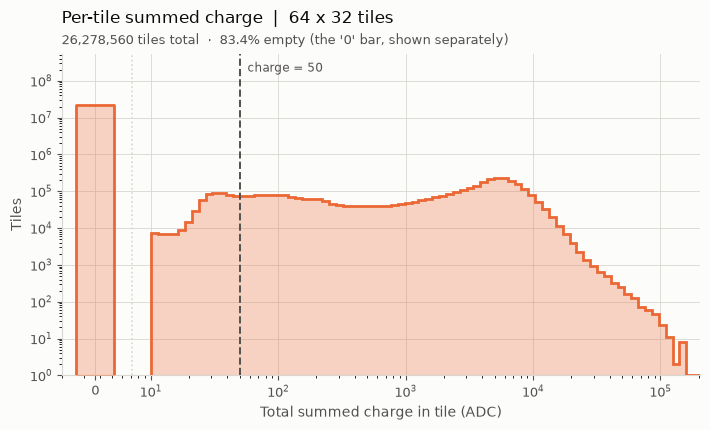

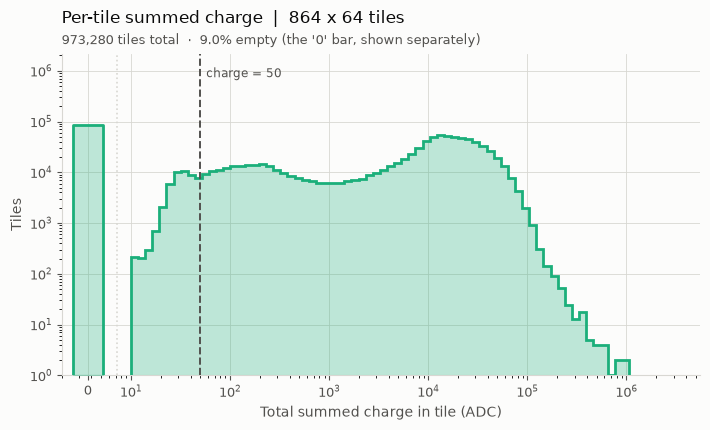

In [5]:
# Three separate histograms of per-tile summed charge, one per tile size.
# Both axes are log: charge spans ~5 decades and the counts span ~9.
#
# Empty tiles (charge exactly 0) cannot sit on a log axis, so they are drawn as
# their own "0" bar in a reserved slot to the LEFT of the continuum, separated
# by a dotted break. At 18x16 that bar holds ~177M tiles against a ~5e5 peak
# bin -- the log y-axis is what makes both readable at once.

COLOR = {(18, 16): "#2a78d6", (64, 32): "#eb6834", (864, 64): "#1baf7a"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#d8d7d2"
Z_LO, Z_HI, SEP = 2.6, 5.2, 7.2      # reserved slot + break position for the "0" bar

for s in SIZES:
    tw, tt = s
    b = BINS[s]
    centers = np.sqrt(b[:-1] * b[1:])           # geometric centres for log bins

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    fig.patch.set_facecolor("#fcfcfb")
    ax.set_facecolor("#fcfcfb")

    # non-empty tiles: the log-binned continuum
    ax.hist(centers, bins=b, weights=counts[s], histtype="stepfilled",
            color=COLOR[s], alpha=0.28, zorder=3)
    ax.hist(centers, bins=b, weights=counts[s], histtype="step",
            color=COLOR[s], linewidth=2.0, zorder=4)
    ax.axvline(CHARGE_MIN, color=INK2, linestyle="--", linewidth=1.4, zorder=5)

    ax.set_xscale("log")
    ax.set_yscale("log")

    top = max(counts[s].max(), n_empty[s]) * 25.0
    lo = max(1.0, counts[s][counts[s] > 0].min() * 0.5) if (counts[s] > 0).any() else 1.0

    # empty tiles (charge == 0), as their own bar left of the continuum
    ax.fill_between([Z_LO, Z_HI], lo, n_empty[s], color=COLOR[s], alpha=0.28, zorder=3)
    ax.plot([Z_LO, Z_LO, Z_HI, Z_HI], [lo, n_empty[s], n_empty[s], lo],
            color=COLOR[s], linewidth=2.0, zorder=4)
    ax.axvline(SEP, color=GRID, linestyle=":", linewidth=1.2, zorder=2)

    ax.set_xlim(2.0, b[-1])
    ax.set_ylim(lo, top)

    decades = [10 ** k for k in range(1, int(np.floor(np.log10(b[-1]))) + 1)]
    ax.set_xticks([np.sqrt(Z_LO * Z_HI)] + decades)
    ax.set_xticklabels(["0"] + [r"$10^{%d}$" % int(np.log10(d)) for d in decades])

    ax.set_xlabel("Total summed charge in tile (ADC)", color=INK2, fontsize=10)
    ax.set_ylabel("Tiles", color=INK2, fontsize=10)
    ax.set_title("Per-tile summed charge  |  %d x %d tiles" % (tw, tt),
                 color=INK, fontsize=12, pad=22, loc="left")
    ax.annotate("%s tiles total  ·  %.1f%% empty (the '0' bar, shown separately)"
                % ("{:,}".format(n_tiles[s]), 100.0 * n_empty[s] / n_tiles[s]),
                xy=(0, 1.02), xycoords="axes fraction", ha="left", va="bottom",
                fontsize=9, color=INK2)
    ax.annotate("charge = %d" % CHARGE_MIN, xy=(CHARGE_MIN * 1.15, top / 2.5),
                fontsize=8.5, color=INK2, ha="left", va="center")

    ax.grid(True, which="major", color=GRID, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9)

    fig.tight_layout()
    plt.show()

### How much neutrino signal does a charge cut throw away?

The histograms above say what fraction of *tiles* a cut removes, which is not the
question that matters. Removing 95% of tiles is harmless if they are empty, and
harmful if neutrino activity is faint. So we measure the cut against truth.

The MicroBooNE open samples are simulated neutrino interactions overlaid on real
beam-off cosmic data. Only the simulated part carries Geant4 truth, so a hit is
**neutrino-induced exactly when it has a Geant4 association** — `edep_table` maps
`hit_id -> g4_id`. Cosmics are real data and carry no truth labels.

For every neutrino hit on plane 2 we find which tile it falls in, look up that
tile's *total* summed charge from the tile catalog, and ask whether the tile
would survive a given cut. Loss is reported both as a fraction of hits and
weighted by hit integral (charge) — the charge-weighted number is the more
physical one, since losing many faint hits matters less than losing a bright one.

In [6]:
RAW_DIR = PROC_DIR.parent          # the original bnb_WithWire_*.h5 live one level up
NU_FILES = 4                       # truth pass is heavy; 4 files ~ 4,300 events ~ 1.1M hits
TIME_FACTOR = 10

# thresholds to scan, log-spaced but forced through the round reference values
THRESH = np.unique(np.concatenate([
    np.round(np.logspace(0, 3.7, 26)),
    [1, 5, 10, 25, 50, 100, 250, 500, 1000, 2000],
])).astype(float)

lost_h = {s: np.zeros(THRESH.size) for s in SIZES}   # neutrino hits below each cut
lost_q = {s: np.zeros(THRESH.size) for s in SIZES}   # same, weighted by hit charge
tot_h = tot_q = 0.0
n_ev = 0

for fi in range(NU_FILES):
    with h5py.File(str(RAW_DIR / ("bnb_WithWire_%02d.h5" % fi)), "r") as f, \
         h5py.File(str(PROC_DIR / ("bnb_WithWire_%02d_tilestats.h5" % fi)), "r") as st:

        hs = f["hit_table/event_id.seq_cnt"][:]          # (event_idx, n_hits)
        h_off = np.concatenate([[0], np.cumsum(hs[:, 1])])
        es = f["edep_table/event_id.seq_cnt"][:]         # sparse: not every event has truth
        e_off = np.concatenate([[0], np.cumsum(es[:, 1])])
        erow = {int(e): i for i, e in enumerate(es[:, 0])}

        plane = f["hit_table/local_plane"][:, 0]
        wire = f["hit_table/local_wire"][:, 0]
        time = f["hit_table/local_time"][:, 0]
        integ = f["hit_table/integral"][:, 0]
        ehit = f["edep_table/hit_id"][:, 0]
        chg = {s: st["%dx%d" % s]["charge"] for s in SIZES}

        for k, ev in enumerate(hs[:, 0]):
            ev = int(ev)
            if ev not in erow:                            # no truth deposits here
                continue
            a, b = int(h_off[k]), int(h_off[k + 1])
            j = erow[ev]
            ids = np.unique(ehit[int(e_off[j]):int(e_off[j + 1])])   # hits with a g4 parent
            ids = ids[(ids >= 0) & (ids < b - a)]
            rows = a + ids
            rows = rows[plane[rows] == 2]                 # collection plane only
            if rows.size == 0:
                continue

            w = wire[rows].astype(np.int64)
            t = (time[rows] / TIME_FACTOR).astype(np.int64)   # tick -> downsampled pixel
            q = integ[rows].astype(np.float64)
            ok = (w >= 0) & (w < 3456) & (t >= 0) & (t < 640)
            w, t, q = w[ok], t[ok], q[ok]
            if w.size == 0:
                continue

            tot_h += w.size; tot_q += q.sum(); n_ev += 1
            for s in SIZES:
                tw, tt = s
                tq = chg[s][ev][(w // tw) * (640 // tt) + (t // tt)]   # the tile's TOTAL charge
                # a hit is discarded at cut c when its tile charge < c; sorting once
                # lets searchsorted answer every threshold in one shot
                o = np.argsort(tq, kind="stable")
                ts, qs = tq[o], q[o]
                k2 = np.searchsorted(ts, THRESH, side="left")
                lost_h[s] += k2
                lost_q[s] += np.concatenate([[0.0], np.cumsum(qs)])[k2]

        del plane, wire, time, integ, ehit

pct_h = {s: 100.0 * lost_h[s] / tot_h for s in SIZES}
pct_q = {s: 100.0 * lost_q[s] / tot_q for s in SIZES}

print("%d events with truth, %s neutrino plane-2 hits\n" % (n_ev, "{:,}".format(int(tot_h))))
i1 = int(np.where(THRESH == 1)[0][0])
print("neutrino hits landing in charge==0 tiles (i.e. lost even by a 'charge > 0' cut):")
for s in SIZES:
    print("   %-8s %4d hits  (%.6f%%)" % ("%dx%d" % s, int(lost_h[s][i1]),
                                          100.0 * lost_h[s][i1] / tot_h))

print("\n%-7s | %-26s | %-26s" % ("cut", "neutrino hits lost (%)", "neutrino charge lost (%)"))
print("%-7s | %8s %8s %8s | %8s %8s %8s"
      % ("", "18x16", "64x32", "864x64", "18x16", "64x32", "864x64"))
print("-" * 68)
for c in [1, 10, 25, 50, 100, 250, 500, 1000, 2000]:
    ci = int(np.where(THRESH == c)[0][0])
    print("%-7.0f | %7.3f%% %7.3f%% %7.3f%% | %7.3f%% %7.3f%% %7.3f%%"
          % (c, pct_h[(18, 16)][ci], pct_h[(64, 32)][ci], pct_h[(864, 64)][ci],
             pct_q[(18, 16)][ci], pct_q[(64, 32)][ci], pct_q[(864, 64)][ci]))

4300 events with truth, 1,127,873 neutrino plane-2 hits

neutrino hits landing in charge==0 tiles (i.e. lost even by a 'charge > 0' cut):
   18x16       3 hits  (0.000266%)
   64x32       1 hits  (0.000089%)
   864x64      0 hits  (0.000000%)

cut     | neutrino hits lost (%)     | neutrino charge lost (%)  
        |    18x16    64x32   864x64 |    18x16    64x32   864x64
--------------------------------------------------------------------
1       |   0.000%   0.000%   0.000% |   0.000%   0.000%   0.000%
10      |   0.000%   0.000%   0.000% |   0.000%   0.000%   0.000%
25      |   0.014%   0.006%   0.000% |   0.004%   0.002%   0.000%
50      |   0.310%   0.133%   0.002% |   0.118%   0.049%   0.001%
100     |   1.271%   0.605%   0.018% |   0.627%   0.285%   0.008%
250     |   4.080%   2.064%   0.113% |   2.790%   1.333%   0.068%
500     |   8.362%   3.887%   0.346% |   6.728%   3.041%   0.250%
1000    |  22.371%   6.181%   0.826% |  17.565%   5.362%   0.683%
2000    |  75.213%  11.352%

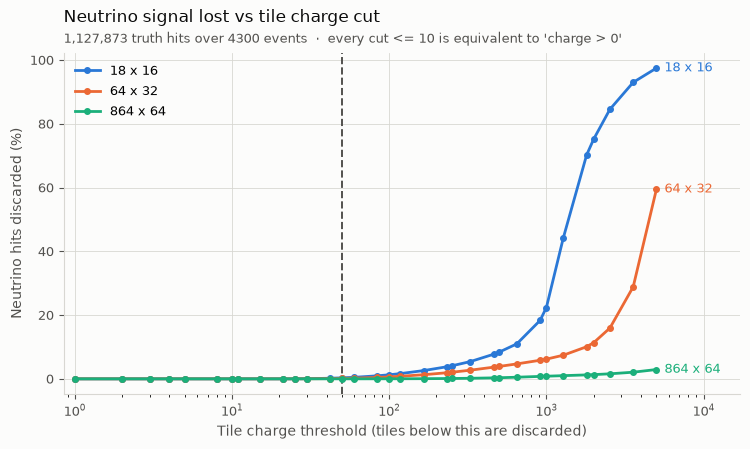

In [7]:
# Neutrino signal lost as a function of the tile charge cut.
# Colour = tile size (same three hues as the histograms above); a legend and
# end-of-line labels both carry identity, so it never rests on colour alone.
#
# Note on the log axes: a series with EXACTLY zero loss cannot be drawn on a log
# y-axis, so the 864x64 curve simply begins where its loss first becomes
# non-zero. The exact zero-cut counts are printed by the cell above.

fig, ax = plt.subplots(figsize=(7.6, 4.6))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

for s in SIZES:
    ax.plot(THRESH, pct_h[s], color=COLOR[s], linewidth=2.0,
            marker="o", markersize=4, label="%d x %d" % s, zorder=4)
    ax.annotate("  %d x %d" % s, xy=(THRESH[-1], pct_h[s][-1]), color=COLOR[s],
                fontsize=9, va="center", ha="left", zorder=5)

ax.axvline(CHARGE_MIN, color=INK2, linestyle="--", linewidth=1.4, zorder=3)
ax.set_xscale("log")

ax.set_xlim(THRESH[0] * 0.85, THRESH[-1] * 3.4)

ax.set_xlabel("Tile charge threshold (tiles below this are discarded)",
              color=INK2, fontsize=10)
ax.set_ylabel("Neutrino hits discarded (%)", color=INK2, fontsize=10)
ax.set_title("Neutrino signal lost vs tile charge cut", color=INK,
             fontsize=12, pad=22, loc="left")
ax.annotate("%s truth hits over %d events  ·  every cut <= 10 is equivalent to 'charge > 0'"
            % ("{:,}".format(int(tot_h)), n_ev),
            xy=(0, 1.02), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=9, color=INK2)
ax.annotate("charge = %d" % CHARGE_MIN, xy=(CHARGE_MIN * 1.15, ax.get_ylim()[0] * 2.2),
            fontsize=8.5, color=INK2, ha="left", va="bottom")

ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(True, which="major", color=GRID, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
for sp in ("left", "bottom"):
    ax.spines[sp].set_color(GRID)
ax.tick_params(colors=INK2, labelsize=9)

fig.tight_layout()
plt.show()

### Imaging non-empty events

A random event is shown as the full collection-plane image (top), then rebuilt
at each tile size from **only the non-empty tiles** stored in
`nonEmptyImages/` by `remove_empty.py`. Tiles that were dropped (zero charge
after cuts) are painted **gray** to mark them as removed and information-less;
kept tiles show their real pixel intensity on the same `jet` scale as the full
image. Because every dropped tile was all-zero, the coloured pixels are
identical to the full image — nothing is lost but the empty space. Set
`FILE_PICK` / `EVENT_PICK` to pin a specific event, or change `SEED`.

showing file 15, event 902 (of 1417)


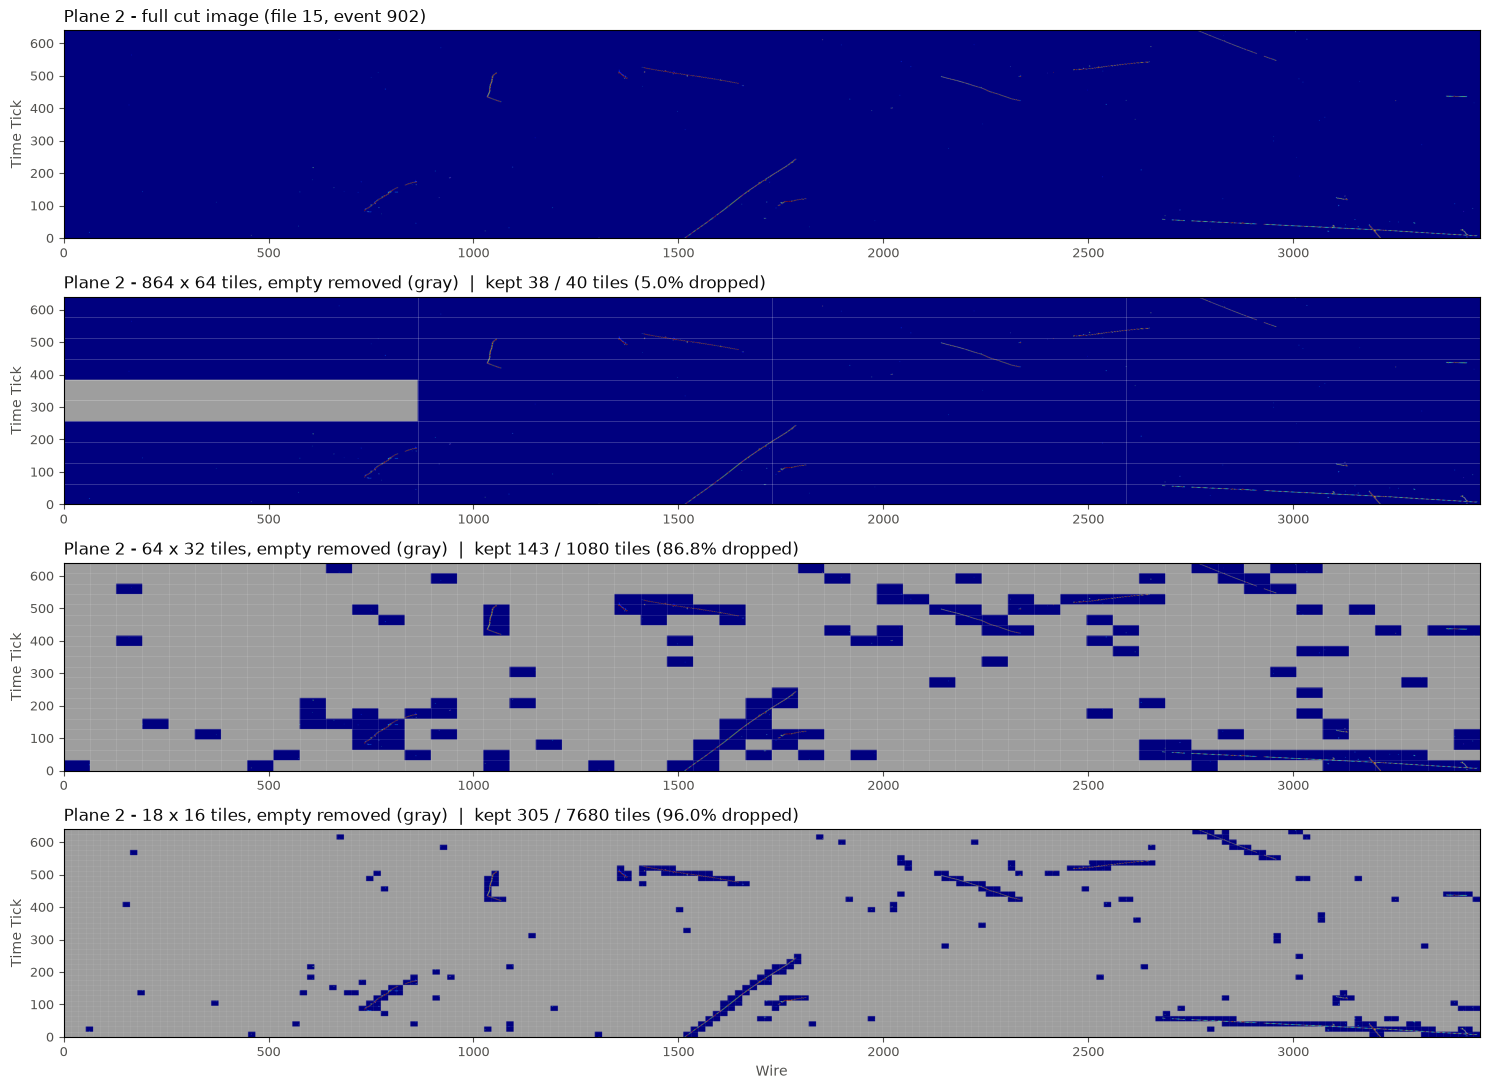

In [8]:
from matplotlib import cm

# NonEmptyTiles lives in remove_empty.py (same folder as this notebook).
try:
    from remove_empty import NonEmptyTiles, apply_cuts
except ImportError:
    import sys
    for _p in (".", "main_project/MBOONE"):     # cwd = notebook dir, or repo root
        if _p not in sys.path:
            sys.path.insert(0, _p)
    from remove_empty import NonEmptyTiles, apply_cuts

NE_DIR = Path("nonEmptyImages")
if not NE_DIR.exists():
    NE_DIR = Path("main_project/MBOONE/nonEmptyImages")

DISPLAY_SIZES = [(864, 64), (64, 32), (18, 16)]     # large -> small
SATVAL = 100.0                                       # jet upper bound (the saturation clip)
GRAY = np.array([0.62, 0.62, 0.62])                  # colour for removed (empty) tiles
INKD, INK2D = "#0b0b0b", "#52514e"

# --- pick an event (random, or pin FILE_PICK / EVENT_PICK) ------------------
SEED = 0
FILE_PICK = None        # e.g. 5 to force a source file
EVENT_PICK = None       # e.g. 3 to force an event
rng = np.random.default_rng(SEED)
FILE = FILE_PICK if FILE_PICK is not None else int(rng.integers(0, 18))

nes = {s: NonEmptyTiles(NE_DIR / ("bnb_WithWire_%02d_plane2_%dx%d_nonempty.h5" % (FILE, s[0], s[1])))
       for s in DISPLAY_SIZES}
n_events = nes[DISPLAY_SIZES[0]].n_events
EVENT = EVENT_PICK if EVENT_PICK is not None else int(rng.integers(0, n_events))
print("showing file %02d, event %d (of %d)" % (FILE, EVENT, n_events))

# full cut image for the reference panel
with h5py.File(str(PROC_DIR / ("bnb_WithWire_%02d_plane2_images.h5" % FILE)), "r") as f:
    d = f["image"]
    full = apply_cuts(d[EVENT], float(d.attrs["default_cutoff"]), float(d.attrs["default_saturation"]))
W, T = full.shape


def masked_rgb(ne, event):
    """(T, W, 3) jet image of one event with dropped (empty) tiles painted gray."""
    img = ne.reconstruct_event(event)                      # (W, T); empty tiles are 0
    rgb = cm.jet(np.clip(img / SATVAL, 0, 1))[..., :3]     # (W, T, 3)
    lo = int(np.searchsorted(ne.event_index, event, "left"))
    hi = int(np.searchsorted(ne.event_index, event, "right"))
    kept = np.zeros((ne.nv, ne.nh), dtype=bool)
    for ti in ne.tile_index[lo:hi]:
        kept[int(ti) // ne.nh, int(ti) % ne.nh] = True     # flat idx = wire_block*nh + time_block
    kept_pix = np.repeat(np.repeat(kept, ne.sw, axis=0), ne.st, axis=1)
    rgb[~kept_pix] = GRAY
    return np.transpose(rgb, (1, 0, 2)), int(kept.sum()), kept.size


fig, axes = plt.subplots(4, 1, figsize=(15, 11))

axes[0].imshow(np.clip(full.T / SATVAL, 0, 1), origin="lower", aspect="auto",
               cmap="jet", vmin=0, vmax=1, extent=[0, W, 0, T])
axes[0].set_title("Plane 2 - full cut image (file %02d, event %d)" % (FILE, EVENT),
                  fontsize=12, color=INKD, loc="left")

for ax, s in zip(axes[1:], DISPLAY_SIZES):
    sw, st = s
    rgb, nk, ntot = masked_rgb(nes[s], EVENT)
    ax.imshow(rgb, origin="lower", aspect="auto", extent=[0, W, 0, T])
    # subtle tile-boundary grid, fading as the grid gets denser
    nlines = (W // sw) + (T // st)
    a = 0.35 if nlines < 40 else (0.18 if nlines < 120 else 0.10)
    ax.vlines(np.arange(sw, W, sw), 0, T, colors="white", lw=0.4, alpha=a)
    ax.hlines(np.arange(st, T, st), 0, W, colors="white", lw=0.4, alpha=a)
    ax.set_xlim(0, W); ax.set_ylim(0, T)
    ax.set_title("Plane 2 - %d x %d tiles, empty removed (gray)  |  kept %d / %d tiles (%.1f%% dropped)"
                 % (sw, st, nk, ntot, 100.0 * (ntot - nk) / ntot),
                 fontsize=12, color=INKD, loc="left")

for ax in axes:
    ax.set_ylabel("Time Tick", fontsize=10, color=INK2D)
    ax.tick_params(labelsize=9, colors=INK2D)
axes[-1].set_xlabel("Wire", fontsize=10, color=INK2D)
fig.tight_layout()
plt.show()

for s in DISPLAY_SIZES:
    nes[s].close()

### Set higher threshold for charge (50)

Use the following commands in order to set the charge threshold to be higher (i.e. 50):

`REMOVE_EMPTY_CHARGE_MIN=50`

`REMOVE_EMPTY_OUT=main_project/MBOONE/nonEmptyImages2`

`conda run --no-capture-output -n ubopendata python main_project/MBOONE/remove_empty.py`

Otherwise the default is 0. Furthermore the files are built to a new folder where you can store say non-zero charge thresholds. If you want to make new ones you may need to delete the files.


showing nonEmptyImages2: file 15, event 902 (of 1417)  [charge >= 50 (after cuts)]


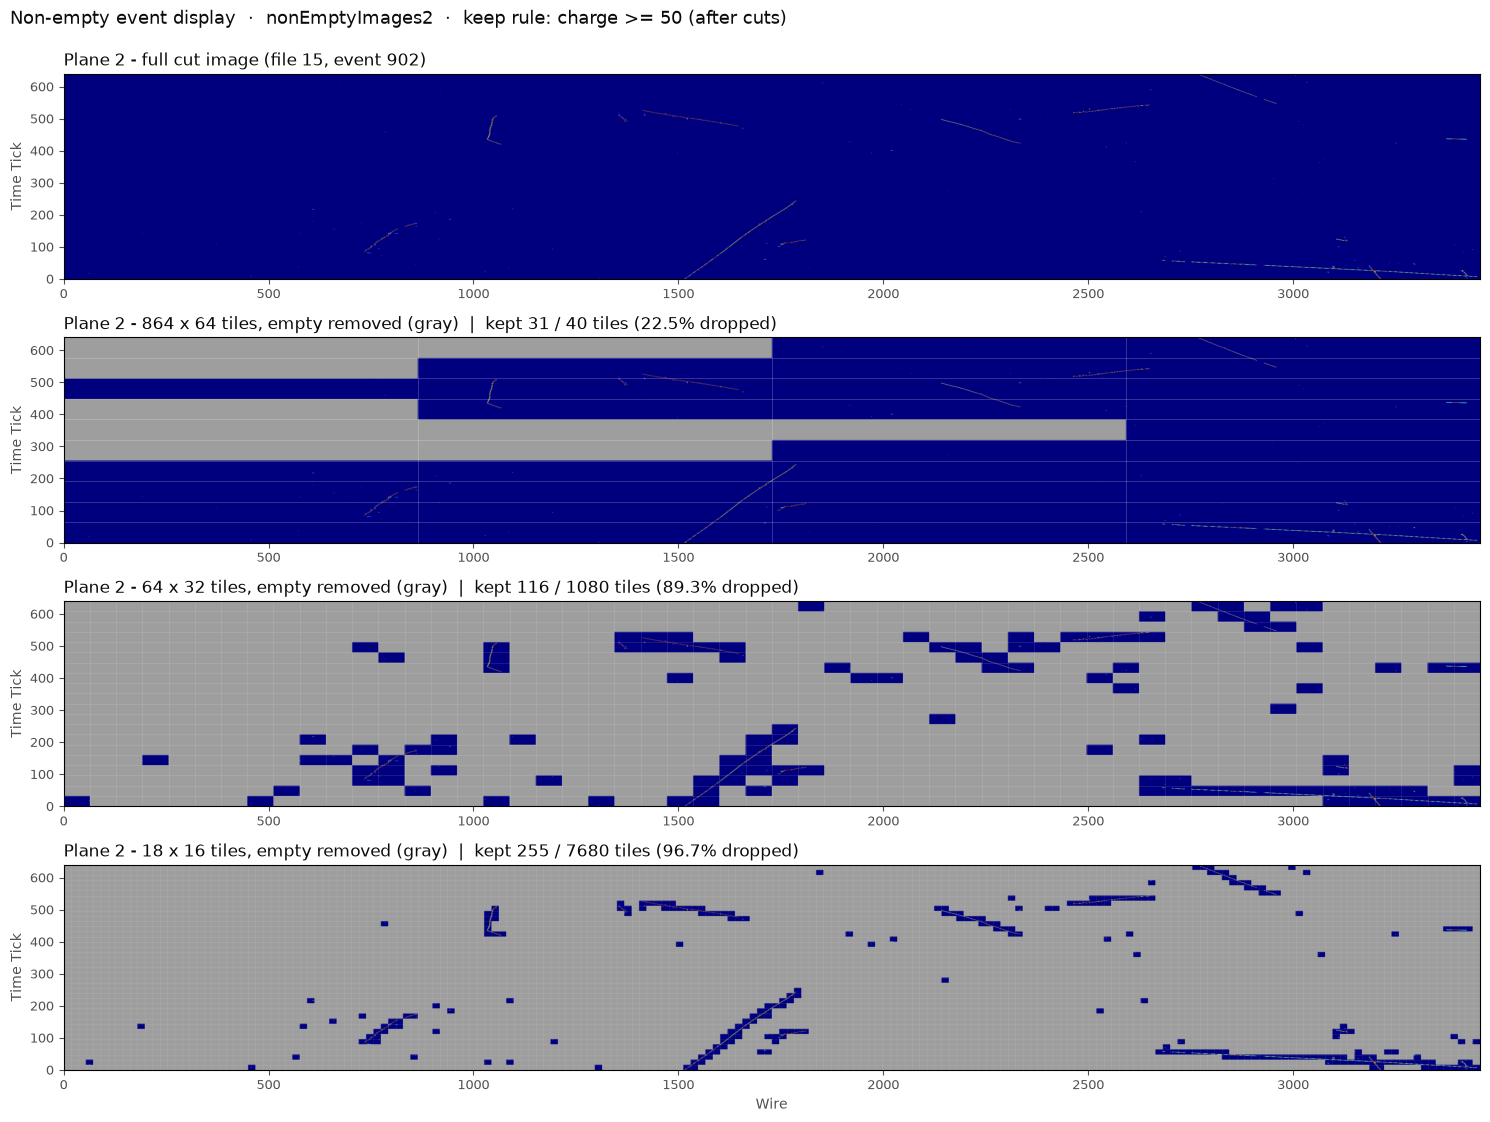

In [9]:
from matplotlib import cm

# NonEmptyTiles lives in remove_empty.py (same folder as this notebook).
try:
    from remove_empty import NonEmptyTiles, apply_cuts
except ImportError:
    import sys
    for _p in (".", "main_project/MBOONE"):     # cwd = notebook dir, or repo root
        if _p not in sys.path:
            sys.path.insert(0, _p)
    from remove_empty import NonEmptyTiles, apply_cuts

# WHICH SET TO DISPLAY -- switch this one line:
#   "nonEmptyImages"   -> charge > 0   (drop only all-zero tiles)
#   "nonEmptyImages2"  -> charge >= 50 (drop faint tiles too)
NE_FOLDER = "nonEmptyImages2"

NE_DIR = Path(NE_FOLDER)
if not NE_DIR.exists():
    NE_DIR = Path("main_project/MBOONE") / NE_FOLDER
assert NE_DIR.exists(), "folder not found: %s -- run remove_empty.py first" % NE_FOLDER

DISPLAY_SIZES = [(864, 64), (64, 32), (18, 16)]     # large -> small
SATVAL = 100.0                                       # jet upper bound (the saturation clip)
GRAY = np.array([0.62, 0.62, 0.62])                  # colour for removed (empty) tiles
INKD, INK2D = "#0b0b0b", "#52514e"

# --- pick an event (random, or pin FILE_PICK / EVENT_PICK) ------------------
SEED = 0
FILE_PICK = None        # e.g. 5 to force a source file
EVENT_PICK = None       # e.g. 3 to force an event
rng = np.random.default_rng(SEED)
FILE = FILE_PICK if FILE_PICK is not None else int(rng.integers(0, 18))

nes = {s: NonEmptyTiles(NE_DIR / ("bnb_WithWire_%02d_plane2_%dx%d_nonempty.h5" % (FILE, s[0], s[1])))
       for s in DISPLAY_SIZES}
n_events = nes[DISPLAY_SIZES[0]].n_events
EVENT = EVENT_PICK if EVENT_PICK is not None else int(rng.integers(0, n_events))
# the tile files record which threshold made them -> label the figure with it
KEEP_RULE = nes[DISPLAY_SIZES[0]].h5.attrs.get("keep_rule", "charge > 0")
print("showing %s: file %02d, event %d (of %d)  [%s]" % (NE_FOLDER, FILE, EVENT, n_events, KEEP_RULE))

# full cut image for the reference panel
with h5py.File(str(PROC_DIR / ("bnb_WithWire_%02d_plane2_images.h5" % FILE)), "r") as f:
    d = f["image"]
    full = apply_cuts(d[EVENT], float(d.attrs["default_cutoff"]), float(d.attrs["default_saturation"]))
W, T = full.shape


def masked_rgb(ne, event):
    """(T, W, 3) jet image of one event with dropped (empty) tiles painted gray."""
    img = ne.reconstruct_event(event)                      # (W, T); empty tiles are 0
    rgb = cm.jet(np.clip(img / SATVAL, 0, 1))[..., :3]     # (W, T, 3)
    lo = int(np.searchsorted(ne.event_index, event, "left"))
    hi = int(np.searchsorted(ne.event_index, event, "right"))
    kept = np.zeros((ne.nv, ne.nh), dtype=bool)
    for ti in ne.tile_index[lo:hi]:
        kept[int(ti) // ne.nh, int(ti) % ne.nh] = True     # flat idx = wire_block*nh + time_block
    kept_pix = np.repeat(np.repeat(kept, ne.sw, axis=0), ne.st, axis=1)
    rgb[~kept_pix] = GRAY
    return np.transpose(rgb, (1, 0, 2)), int(kept.sum()), kept.size


fig, axes = plt.subplots(4, 1, figsize=(15, 11.4))
fig.suptitle("Non-empty event display  ·  %s  ·  keep rule: %s"
             % (NE_FOLDER, KEEP_RULE), fontsize=13, color=INKD, x=0.01, ha="left")

axes[0].imshow(np.clip(full.T / SATVAL, 0, 1), origin="lower", aspect="auto",
               cmap="jet", vmin=0, vmax=1, extent=[0, W, 0, T])
axes[0].set_title("Plane 2 - full cut image (file %02d, event %d)" % (FILE, EVENT),
                  fontsize=12, color=INKD, loc="left")

for ax, s in zip(axes[1:], DISPLAY_SIZES):
    sw, st = s
    rgb, nk, ntot = masked_rgb(nes[s], EVENT)
    ax.imshow(rgb, origin="lower", aspect="auto", extent=[0, W, 0, T])
    # subtle tile-boundary grid, fading as the grid gets denser
    nlines = (W // sw) + (T // st)
    a = 0.35 if nlines < 40 else (0.18 if nlines < 120 else 0.10)
    ax.vlines(np.arange(sw, W, sw), 0, T, colors="white", lw=0.4, alpha=a)
    ax.hlines(np.arange(st, T, st), 0, W, colors="white", lw=0.4, alpha=a)
    ax.set_xlim(0, W); ax.set_ylim(0, T)
    ax.set_title("Plane 2 - %d x %d tiles, empty removed (gray)  |  kept %d / %d tiles (%.1f%% dropped)"
                 % (sw, st, nk, ntot, 100.0 * (ntot - nk) / ntot),
                 fontsize=12, color=INKD, loc="left")

for ax in axes:
    ax.set_ylabel("Time Tick", fontsize=10, color=INK2D)
    ax.tick_params(labelsize=9, colors=INK2D)
axes[-1].set_xlabel("Wire", fontsize=10, color=INK2D)
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

for s in DISPLAY_SIZES:
    nes[s].close()

## Autoencoder training

The autoencoder architecture and training procedure will follow nearly identically to the tutorial. The saved models and information and loss/validation loss will also be in the `main_project/MBOONE/savedModel` folder each under individual subfolders correlating to the charge thresholds imposed. As such we need to train the autoencoder effectively 6 times, each charge threshold gets their own unique.

Note: a key difference here is we will NOT be converting our `.h5` files into `.npy` files due to storage reasons. The computer needs to have signficiantly more storage than a typical PC or Laptop run on CPUs and therefore the new training script will be adapted to take in `.h5` files instead thus diverging from the FIREFLY and our tutorial autoencoder. 

Now another key point that should be made is to ensure you train the `MBOONE_Training.py` on the `scarab` virtual environment/conda environment. Run it using the following command:

`conda run --no-capture-output -n scarab python main_project/MBOONE/MBOONE_Training.py`

For our purposes we will be training the charge threshold $Q \geq 50$ training data for all tile sizes to go in the `savedModel/Q50` subfolder.



In [10]:
# ---- Shared plotting + path helpers for the study plots below ----
# Each study defines a draw_panel(ax, size) and calls render_study(...):
# it first draws a MERGED superplot with all sizes side by side, then draws
# EACH size as its own separate figure -- so you can download the combined view
# or any individual plot. (N sizes -> 1 merged + N individual figures.)
# Run this cell once before the study cells below.

# Self-contained imports so this section runs even in a fresh kernel that
# hasn't executed the cells higher up.
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

SAVE_DIR = Path("savedModel/Q50")
if not SAVE_DIR.exists():                       # if the kernel's cwd is the repo root
    SAVE_DIR = Path("main_project/MBOONE/savedModel/Q50")
NE_DIR = Path("nonEmptyImages2")
if not NE_DIR.exists():
    NE_DIR = Path("main_project/MBOONE/nonEmptyImages2")

INK, INK2, GRIDC = "#0b0b0b", "#52514e", "#d8d7d2"
SIZE_COLOR = {(864, 64): "#1baf7a", (64, 32): "#eb6834", (18, 16): "#2a78d6"}

def _style_ax(ax):
    """Common chrome: light grid, no top/right spines, muted ticks."""
    ax.set_facecolor("#fcfcfb")
    ax.grid(True, which="major", color=GRIDC, linewidth=0.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRIDC)
    ax.tick_params(colors=INK2, labelsize=9)

def render_study(sizes, draw_panel, suptitle, panel_w=6.2, panel_h=4.4, individual=True):
    """Render one study as a merged superplot AND one figure per size.

    draw_panel(ax, size) must draw a single panel for one tile size onto ax.
    """
    # (1) merged superplot: all sizes side by side
    fig, axes = plt.subplots(1, len(sizes), figsize=(panel_w * len(sizes), panel_h), squeeze=False)
    fig.patch.set_facecolor("#fcfcfb")
    for ax, s in zip(axes[0], sizes):
        draw_panel(ax, s)
        _style_ax(ax)
    fig.suptitle(suptitle, fontsize=13, color=INK)
    fig.tight_layout()
    plt.show()
    # (2) each size on its own, for individual download
    if individual:
        for s in sizes:
            fig, ax = plt.subplots(figsize=(panel_w, panel_h))
            fig.patch.set_facecolor("#fcfcfb")
            draw_panel(ax, s)
            _style_ax(ax)
            fig.tight_layout()
            plt.show()

### Loss plots 

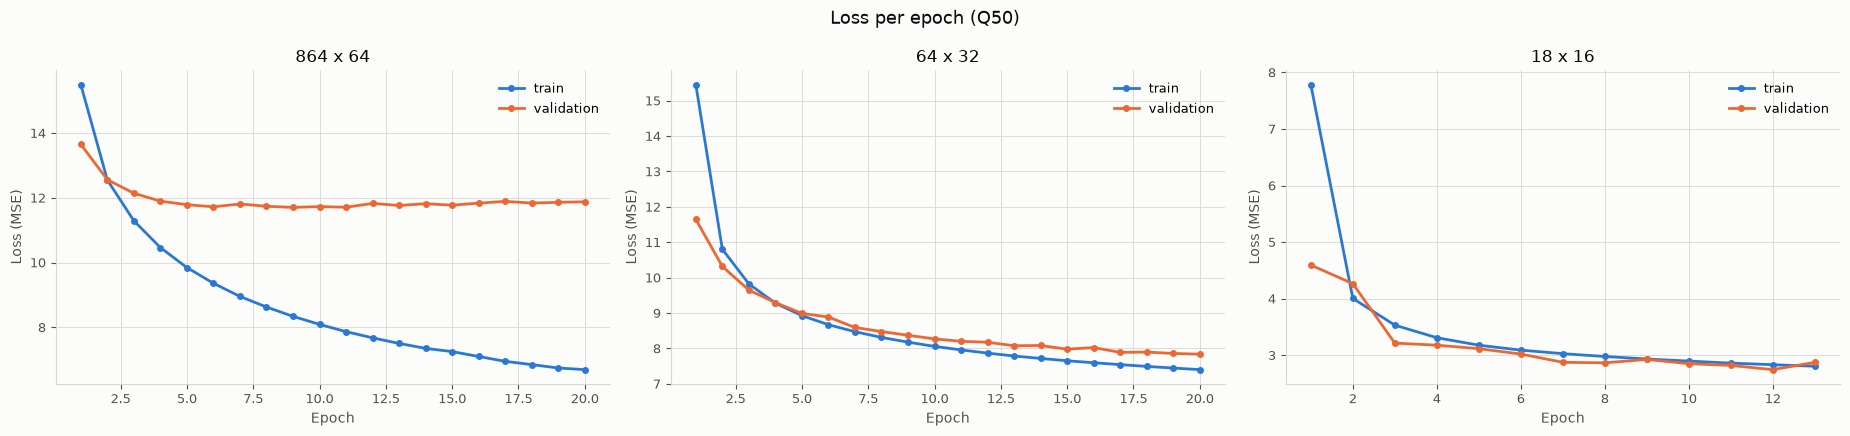

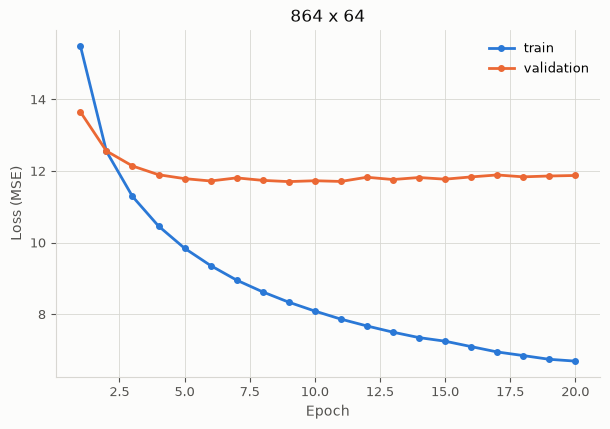

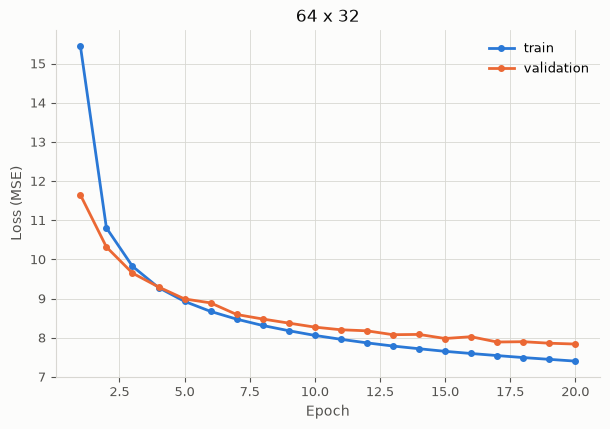

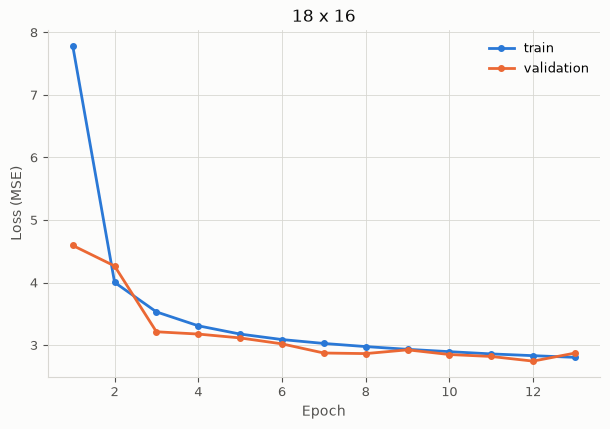

In [11]:
# Training vs. validation loss (MSE) per epoch, from the Q50 history CSVs.
# Renders the merged superplot then each size on its own (see render_study above).
LOSS_SIZES = [(864, 64), (64, 32), (18, 16)]

def loss_panel(ax, s):
    sw, st = s
    d = np.loadtxt(str(SAVE_DIR / ("unsupervised_%dx%d_history.csv" % (sw, st))),
                   delimiter=",", skiprows=1)          # columns: epoch, loss, val_loss
    ep = d[:, 0] + 1                                    # 1-based epochs
    ax.plot(ep, d[:, 1], color="#2a78d6", lw=2, marker="o", ms=4, label="train")
    ax.plot(ep, d[:, 2], color="#eb6834", lw=2, marker="o", ms=4, label="validation")
    ax.set_title("%d x %d" % (sw, st), color=INK, fontsize=12)
    ax.set_xlabel("Epoch", color=INK2, fontsize=10)
    ax.set_ylabel("Loss (MSE)", color=INK2, fontsize=10)
    ax.legend(frameon=False, fontsize=9)

render_study(LOSS_SIZES, loss_panel, "Loss per epoch (Q50)")

### Anomaly Score Histograms

864x64: scored 20000 tiles

64x32: scored 20000 tiles
18x16: scored 20000 tiles


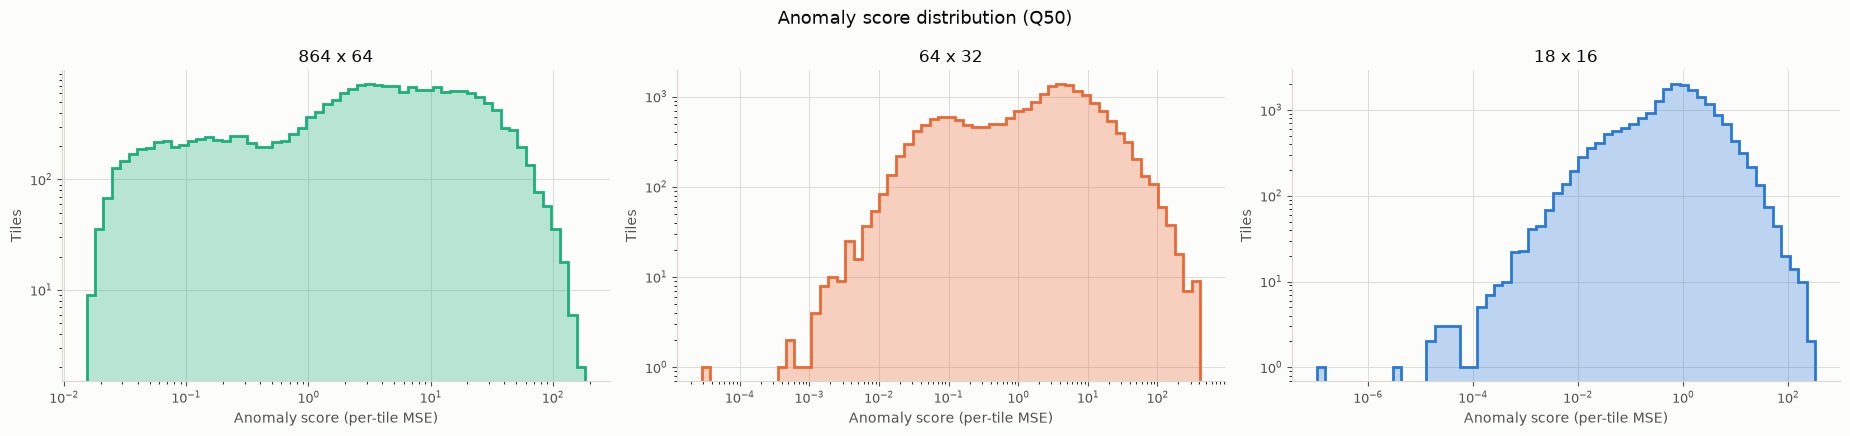

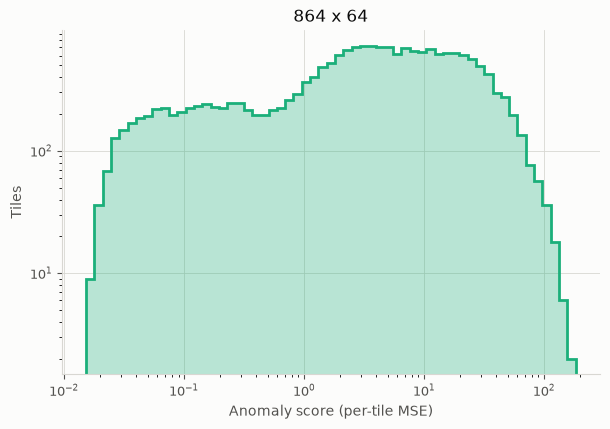

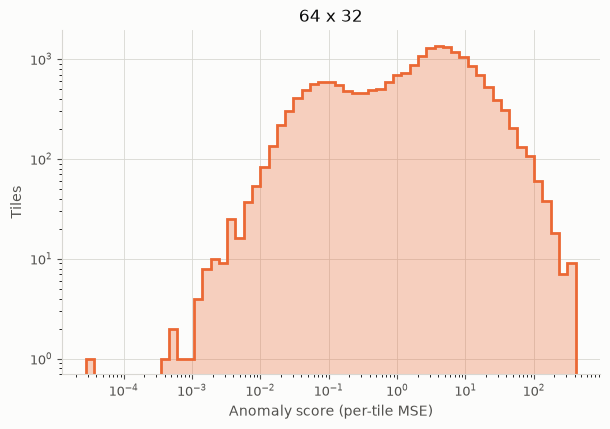

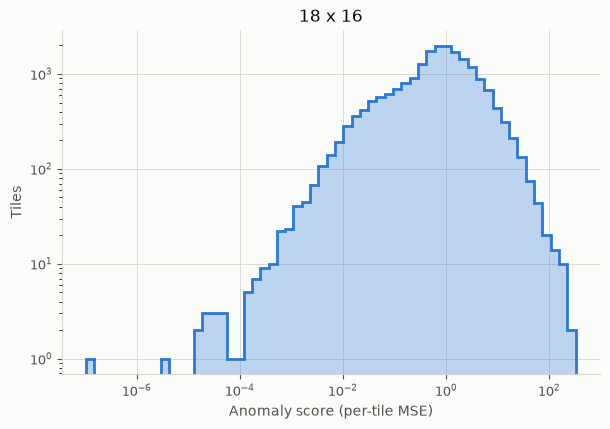

In [12]:
# Anomaly-score (per-tile reconstruction MSE) distribution for each Q50 model.
# Needs the scarab env (TensorFlow). Tiles are scored in small CHUNKS and only the
# scalar scores are kept -- holding all the 864x64 tiles densely would be ~6.6 GB
# per array (input + reconstruction + temp ~ 20 GB) and OOM-crash the kernel.
from tensorflow import keras
try:
    from MBOONE_Training import anomaly_score
except ImportError:
    import sys
    for _p in (".", "main_project/MBOONE"):
        if _p not in sys.path:
            sys.path.insert(0, _p)
    from MBOONE_Training import anomaly_score

HIST_SIZES = [(864, 64), (64, 32), (18, 16)]
MAX_TILES = 20000                      # tiles scored per size (runtime knob)
CHUNK = 512                            # tiles held in RAM at once (memory knob)

def score_sample(model, sw, st, max_tiles):
    """Score up to max_tiles tiles (spread across the 18 files) in small chunks,
    keeping only the per-tile scores so peak memory stays at ~one CHUNK."""
    scores, got = [], 0
    per_file = max_tiles // 18 + 1
    for fnum in range(18):
        p = NE_DIR / ("bnb_WithWire_%02d_plane2_%dx%d_nonempty.h5" % (fnum, sw, st))
        if not p.exists():
            continue
        with h5py.File(str(p), "r") as f:
            d = f["tiles"]
            take = min(d.shape[0], per_file, max_tiles - got)
            for i in range(0, take, CHUNK):
                X = d[i:min(i + CHUNK, take)][..., None].astype("float32")
                scores.append(anomaly_score(model, X, batch_size=256))
                del X
            got += take
        if got >= max_tiles:
            break
    return np.concatenate(scores) if scores else np.array([])

SCORES = {}
for sw, st in HIST_SIZES:
    model = keras.models.load_model(str(SAVE_DIR / ("unsupervised_%dx%d.h5" % (sw, st))),
                                    compile=False)
    SCORES[(sw, st)] = score_sample(model, sw, st, MAX_TILES)
    print("%dx%d: scored %d tiles" % (sw, st, len(SCORES[(sw, st)])))
    del model
    keras.backend.clear_session()

def score_hist_panel(ax, s):
    sc = SCORES[s]
    sc = sc[sc > 0]                                     # log x-axis needs positive scores
    bins = np.logspace(np.log10(sc.min()), np.log10(sc.max()), 60)
    ax.hist(sc, bins=bins, color=SIZE_COLOR[s], alpha=0.3)
    ax.hist(sc, bins=bins, histtype="step", color=SIZE_COLOR[s], linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("%d x %d" % s, color=INK, fontsize=12)
    ax.set_xlabel("Anomaly score (per-tile MSE)", color=INK2, fontsize=10)
    ax.set_ylabel("Tiles", color=INK2, fontsize=10)

render_study(HIST_SIZES, score_hist_panel, "Anomaly score distribution (Q50)")

### Reconstruction v.s. Input

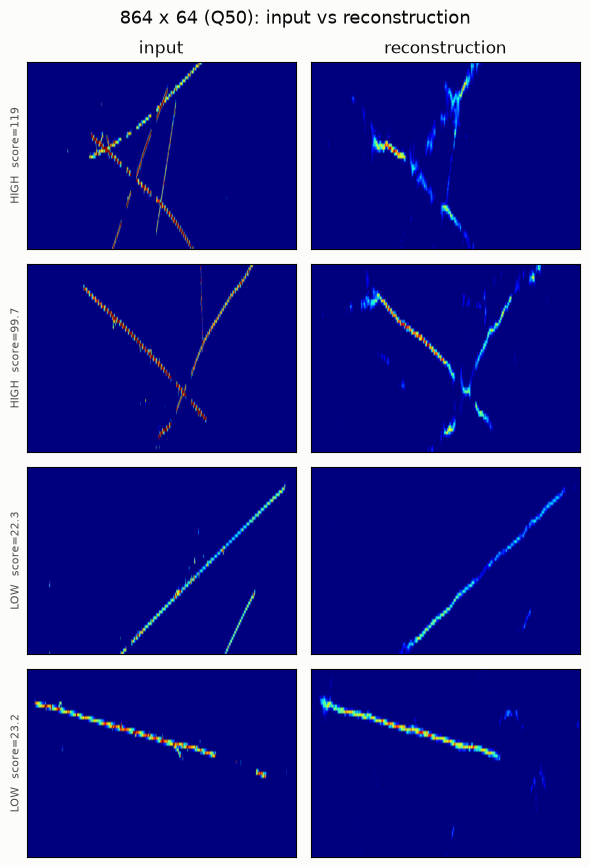

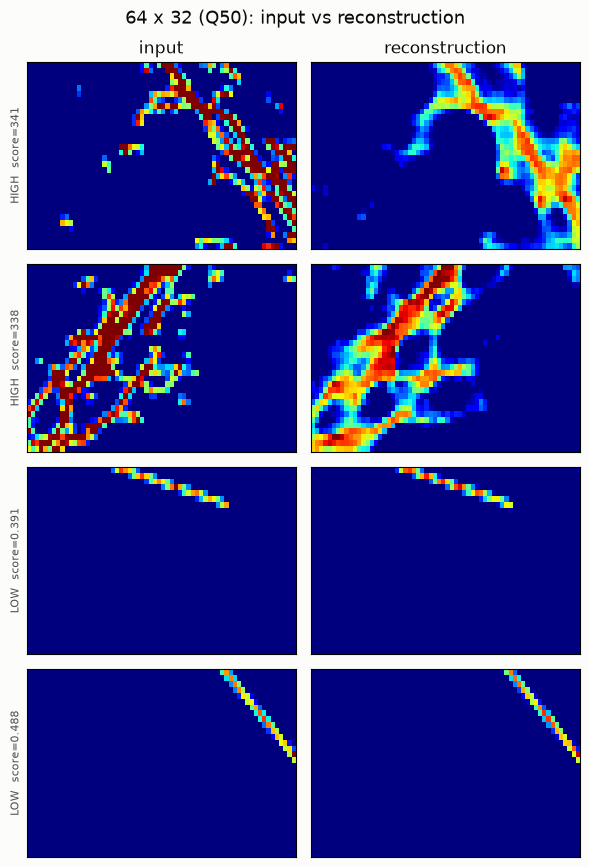

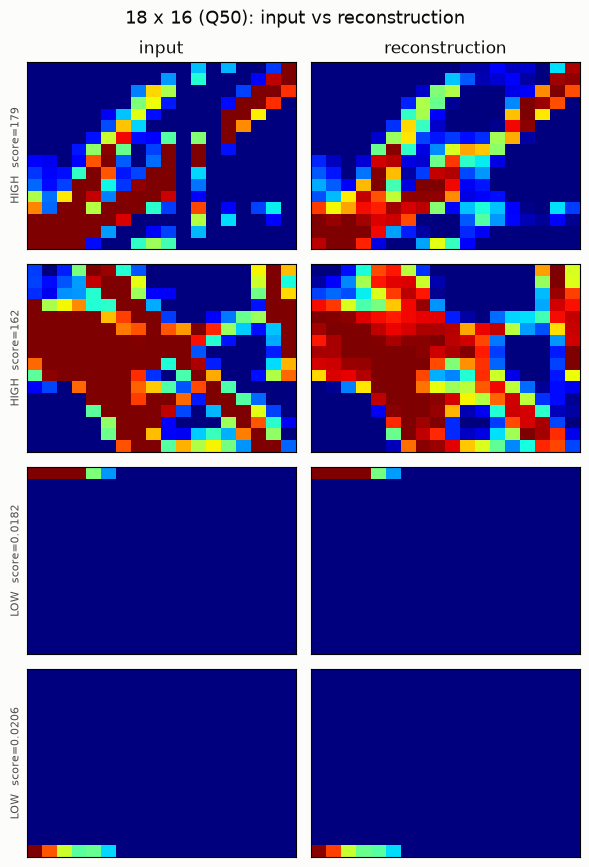

In [13]:
# Input vs reconstruction for the highest- and lowest-anomaly non-empty tiles,
# one figure per tile size (paper Fig. 7). HIGH anomaly = multi-track topology
# the model reconstructs poorly; LOW anomaly = a single clean track it reproduces
# well. Needs the scarab env; scores a sample per size to find the extremes.
from tensorflow import keras
try:
    from MBOONE_Training import anomaly_score
except ImportError:
    import sys
    for _p in (".", "main_project/MBOONE"):
        if _p not in sys.path:
            sys.path.insert(0, _p)
    from MBOONE_Training import anomaly_score

RECON_SIZES = [(864, 64), (64, 32), (18, 16)]
RECON_SAMPLE = {(864, 64): 1500, (64, 32): 5000, (18, 16): 5000}   # tiles scored to find extremes
MIN_LIT_FRAC = 0.02                                                # only tiles with a real track

for sw, st in RECON_SIZES:
    model = keras.models.load_model(str(SAVE_DIR / ("unsupervised_%dx%d.h5" % (sw, st))), compile=False)
    cap, chunks, got = RECON_SAMPLE[(sw, st)], [], 0
    for fnum in range(18):
        p = NE_DIR / ("bnb_WithWire_%02d_plane2_%dx%d_nonempty.h5" % (fnum, sw, st))
        if not p.exists():
            continue
        with h5py.File(str(p), "r") as fh:
            take = min(fh["tiles"].shape[0], cap // 18 + 1, cap - got)
            if take > 0:
                chunks.append(fh["tiles"][:take][..., None].astype("float32")); got += take
        if got >= cap:
            break
    X = np.concatenate(chunks, axis=0)
    sc = anomaly_score(model, X, batch_size=16 if sw >= 864 else 256)
    frac = (X > 0).reshape(len(X), -1).mean(axis=1)
    order = np.argsort(sc)
    pool = order[frac[order] >= MIN_LIT_FRAC]           # only tiles that actually contain a track
    picks = list(pool[-2:][::-1]) + list(pool[:2])      # 2 highest, then 2 lowest anomaly
    tags = ["HIGH", "HIGH", "LOW", "LOW"]
    recon = model.predict(X[picks], verbose=0, batch_size=64)

    fig, axes = plt.subplots(len(picks), 2, figsize=(6, 2.2 * len(picks)))
    fig.patch.set_facecolor("#fcfcfb")
    for r, (k, tag) in enumerate(zip(picks, tags)):
        vmax = max(1.0, float(X[k].max()))
        axes[r, 0].imshow(X[k, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
        axes[r, 0].set_ylabel("%s  score=%.3g" % (tag, sc[k]), fontsize=8, color=INK2)
        axes[r, 1].imshow(recon[r, :, :, 0].T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
        for c in (0, 1):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[0, 0].set_title("input", color=INK); axes[0, 1].set_title("reconstruction", color=INK)
    fig.suptitle("%d x %d (Q50): input vs reconstruction" % (sw, st), fontsize=13, color=INK)
    fig.tight_layout()
    plt.show()
    del X, model
    keras.backend.clear_session()

### ROC-AUC

864x64: 6697 tiles scored, n(>=3 tracks)=153
64x32: 8024 tiles scored, n(>=3 tracks)=118
18x16: 10838 tiles scored, n(>=3 tracks)=76


C:\Users\aidan\AppData\Local\Temp\ipykernel_29356\1777237728.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return fpr, tpr, float(np.trapz(tpr, fpr))


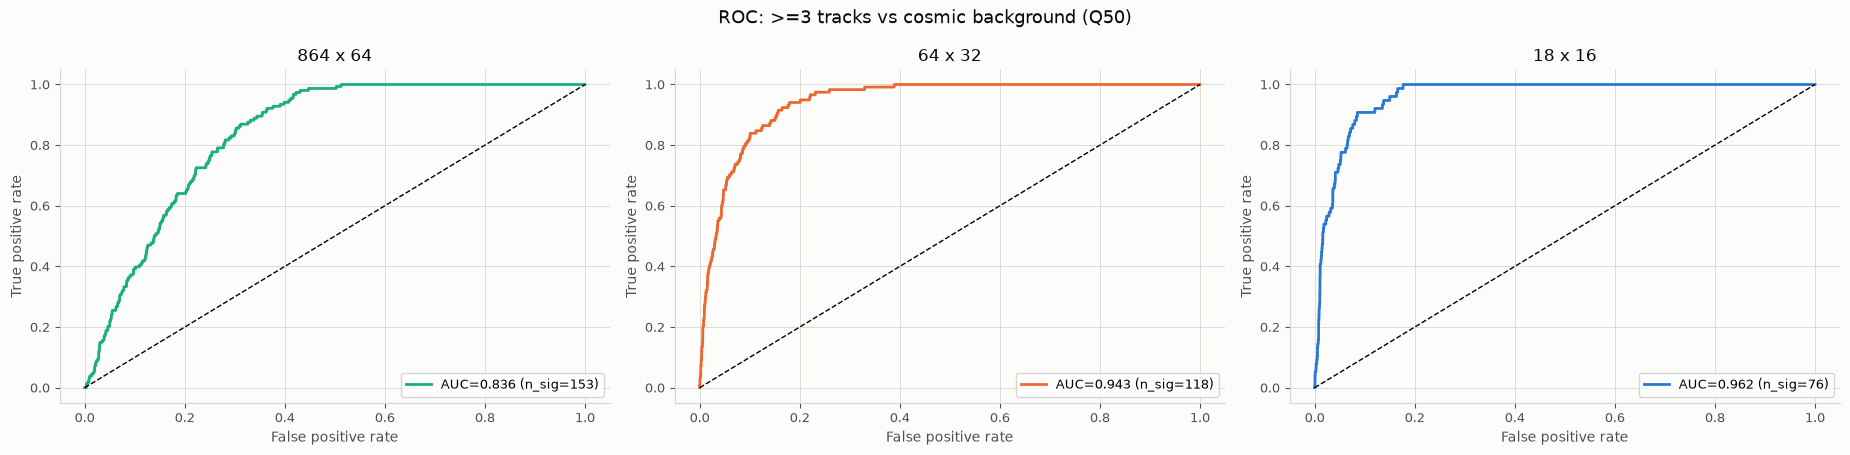

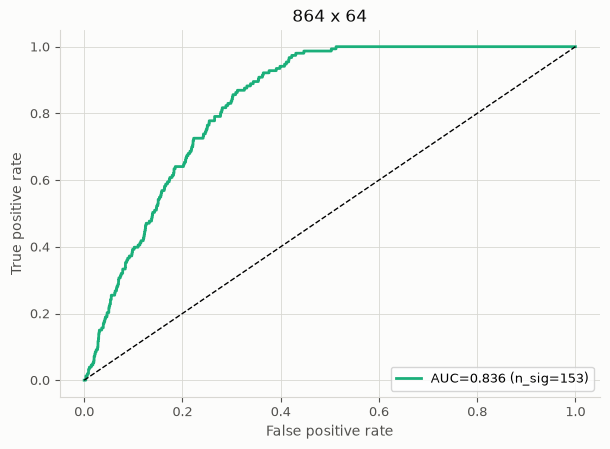

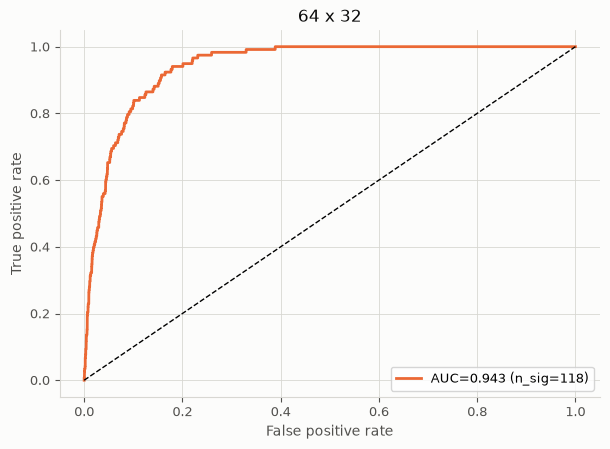

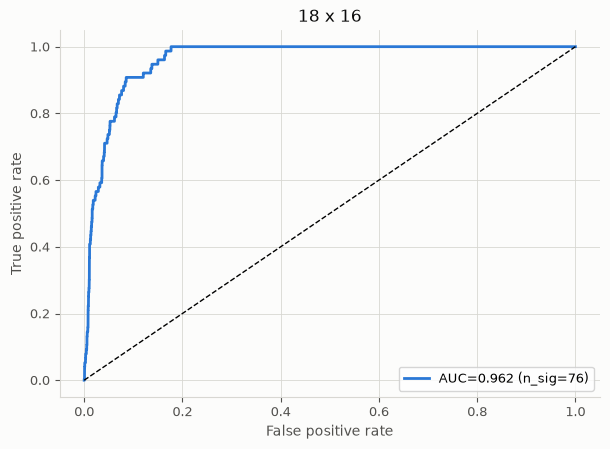

In [14]:
# ROC-AUC for >=3-track tiles vs cosmic background, all three cuts.
# Track count per tile from Geant4 truth: each plane-2 hit -> its dominant g4_id
# (via edep energy fraction); a "track" in a tile = a g4_id with >=MIN_HITS hits.
# Signal = tiles with >=NREQ tracks; background = non-empty tiles with 0 truth
# tracks (cosmic). Needs the scarab env; reads raw truth from bnb_WithWire_00.h5.
# Also stores roc_intensity (total charge per scored tile) for the SCALED-score
# cell below. NOTE: this "vs cosmic" signal differs from the paper's Table 3
# ("N-track vs low-multiplicity"). All 18 files were in training, so file 00 is
# not a fully held-out set (mild here).
from tensorflow import keras
try:
    from MBOONE_Training import anomaly_score
    from remove_empty import apply_cuts, split_into_segments
except ImportError:
    import sys
    for _p in (".", "main_project/MBOONE"):
        if _p not in sys.path:
            sys.path.insert(0, _p)
    from MBOONE_Training import anomaly_score
    from remove_empty import apply_cuts, split_into_segments

# PROC_DIR (processed images + raw files) -- resolve here so this cell is standalone.
PROC_DIR = Path("../../data/ubopendata/processed_npy")
if not PROC_DIR.exists():
    PROC_DIR = Path("data/ubopendata/processed_npy")

def roc_curve_auc(y, sc):
    """ROC curve + trapezoidal AUC in pure numpy (scarab's sklearn DLLs are broken)."""
    y = np.asarray(y).astype(int); sc = np.asarray(sc, float)
    order = np.argsort(-sc); y = y[order]
    P, N = int(y.sum()), len(y) - int(y.sum())
    tpr = np.concatenate([[0.0], np.cumsum(y) / P])
    fpr = np.concatenate([[0.0], np.cumsum(1 - y) / N])
    return fpr, tpr, float(np.trapz(tpr, fpr))

ROC_SIZES = [(864, 64), (64, 32), (18, 16)]
NREQ, MIN_HITS, N_EVENTS, BG_CAP = 3, 5, 400, 15
PB = {(864, 64): 16, (64, 32): 256, (18, 16): 512}     # predict batch per size
rng = np.random.default_rng(0)

RAW = PROC_DIR.parent / "bnb_WithWire_00.h5"
IMG = PROC_DIR / "bnb_WithWire_00_plane2_images.h5"
f = h5py.File(str(RAW), "r")
hit_off = np.concatenate([[0], np.cumsum(f["hit_table/event_id.seq_cnt"][:, 1])])
esc = f["edep_table/event_id.seq_cnt"][:]
e_evid = esc[:, 0]; e_start = np.concatenate([[0], np.cumsum(esc[:, 1])])

def plane2_g4(e):
    """(local_wire, local_time, dominant g4_id) for plane-2 hits of event e."""
    hlo, hhi = int(hit_off[e]), int(hit_off[e + 1])
    p2 = f["hit_table/local_plane"][hlo:hhi, 0] == 2
    if not p2.any():
        return None
    hid = f["hit_table/hit_id"][hlo:hhi, 0][p2]
    lw = f["hit_table/local_wire"][hlo:hhi, 0][p2]
    lt = f["hit_table/local_time"][hlo:hhi, 0][p2]
    i = np.searchsorted(e_evid, e); dom = {}
    if i < len(e_evid) and e_evid[i] == e:
        elo, ehi = int(e_start[i]), int(e_start[i] + esc[i, 1])
        eh = f["edep_table/hit_id"][elo:ehi, 0]
        eg = f["edep_table/g4_id"][elo:ehi, 0]
        ef = f["edep_table/energy_fraction"][elo:ehi, 0]
        for j in np.argsort(-ef):                       # dominant contributor per hit first
            k = int(eh[j])
            if k not in dom:
                dom[k] = int(eg[j])
    return lw, lt, np.array([dom.get(int(h), -1) for h in hid])

imf = h5py.File(str(IMG), "r")
d_img = imf["image"]
cutoff = float(d_img.attrs["default_cutoff"]); sat = float(d_img.attrs["default_saturation"])
n_ev = min(N_EVENTS, d_img.shape[0])

roc_results = {}       # (sw,st) -> (anomaly_score, n_tracks) per scored tile
roc_intensity = {}     # (sw,st) -> total pixel charge per scored tile (for scaled score)
for sw, st in ROC_SIZES:
    model = keras.models.load_model(str(SAVE_DIR / ("unsupervised_%dx%d.h5" % (sw, st))), compile=False)
    h_split = 640 // st
    Sc, Nt, It = [], [], []
    for e in range(n_ev):
        segs = split_into_segments(apply_cuts(d_img[e], cutoff, sat), sw, st)[..., None]
        lit = (segs > 0).reshape(len(segs), -1).sum(1)
        nt = np.zeros(len(segs), dtype=int)
        g = plane2_g4(e)
        if g is not None:
            lw, lt, g4 = g
            tile = (lw // sw).astype(int) * h_split + ((lt // 10) // st).astype(int)
            ok = (tile >= 0) & (tile < len(segs)); tile, g4 = tile[ok], g4[ok]
            for t in np.unique(tile):
                gg = g4[tile == t]; gg = gg[gg >= 0]
                if gg.size:
                    _, c = np.unique(gg, return_counts=True)
                    nt[t] = int((c >= MIN_HITS).sum())      # tracks = g4_ids with >=5 hits here
        sig = np.where(nt >= 1)[0]                            # score ALL signal tiles
        bg = np.where((nt == 0) & (lit > 0))[0]              # + a per-event cosmic-background sample
        if len(bg) > BG_CAP:
            bg = rng.choice(bg, BG_CAP, replace=False)
        sel = np.concatenate([sig, bg]).astype(int)
        if len(sel):
            Sc.append(anomaly_score(model, segs[sel], batch_size=PB[(sw, st)]))
            Nt.append(nt[sel])
            It.append(segs[sel].sum(axis=(1, 2, 3)))         # total charge per tile
    roc_results[(sw, st)] = (np.concatenate(Sc), np.concatenate(Nt))
    roc_intensity[(sw, st)] = np.concatenate(It)
    print("%dx%d: %d tiles scored, n(>=%d tracks)=%d"
          % (sw, st, len(roc_results[(sw, st)][1]), NREQ, int((roc_results[(sw, st)][1] >= NREQ).sum())))
    del model
    keras.backend.clear_session()
f.close(); imf.close()

def roc_panel(ax, s):
    Sc, Nt = roc_results[s]
    pos = Nt >= NREQ; sub = pos | (Nt == 0)
    if pos.sum() == 0 or (Nt == 0).sum() == 0:
        ax.text(0.5, 0.5, "insufficient signal/background", ha="center", va="center", color=INK2)
    else:
        fpr, tpr, auc = roc_curve_auc(pos[sub], Sc[sub])
        ax.plot(fpr, tpr, color=SIZE_COLOR[s], lw=2, label="AUC=%.3f (n_sig=%d)" % (auc, int(pos.sum())))
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("%d x %d" % s, color=INK, fontsize=12)
    ax.set_xlabel("False positive rate", color=INK2, fontsize=10)
    ax.set_ylabel("True positive rate", color=INK2, fontsize=10)
    ax.legend(loc="lower right", fontsize=9)

render_study(ROC_SIZES, roc_panel, "ROC: >=%d tracks vs cosmic background (Q50)" % NREQ, panel_h=4.6)

C:\Users\aidan\AppData\Local\Temp\ipykernel_29356\1777237728.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return fpr, tpr, float(np.trapz(tpr, fpr))


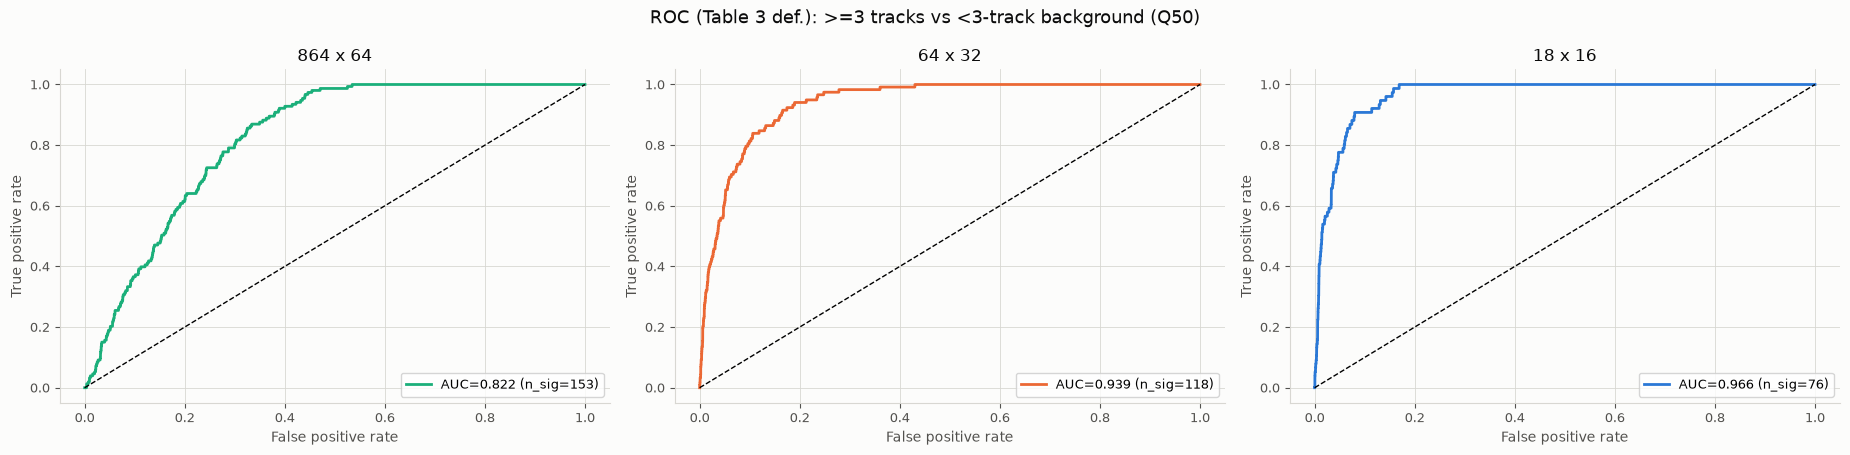

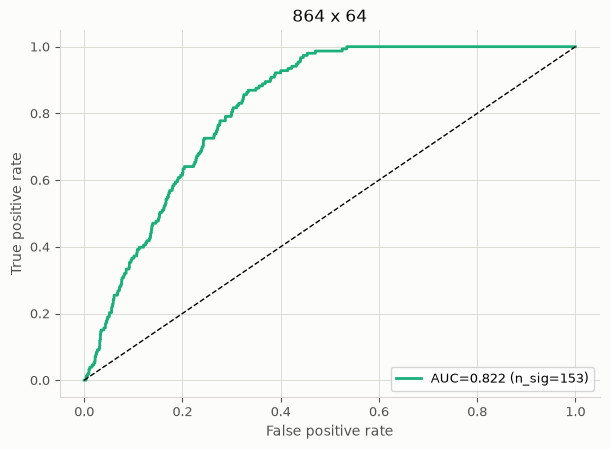

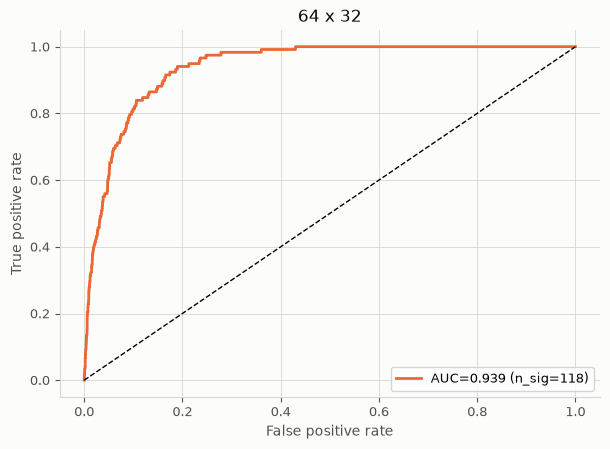

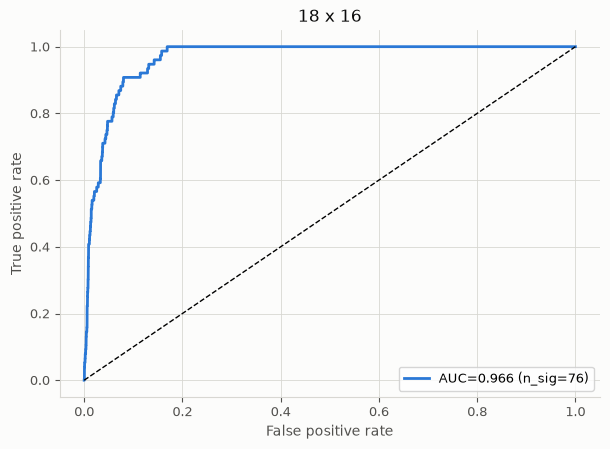

In [15]:
# Same scored tiles, but the paper's Table 3 SIGNAL DEFINITION: signal = >=NREQ
# tracks, background = ALL tiles with FEWER than NREQ tracks (0/1/2-track,
# non-empty) -- a pure multiplicity test, not "vs cosmic 0-track" like the cell
# above. The 1- and 2-track tiles were already scored above (they are in nt >= 1),
# so this just reuses roc_results -- no re-scoring. Run the ROC cell above first.
#
# INTERPRETATION -- do NOT expect the paper's exact 0.934 / 0.854 / 0.499:
#   * These are our unsupervised-AE (Teacher-analog) scores; Table 3 is the
#     QUANTIZED STUDENT. Its 18x16 = 0.499 is a quantization + tiny-network
#     collapse the full-precision AE does not share, so a high 18x16 here is
#     expected, not a bug.
#   * This uses the REGULAR anomaly score, which separates partly via total
#     charge (more tracks -> more charge). The paper's SCALED score divides that
#     out to isolate topology; scaled_anomaly_score() in MBOONE_Training.py would
#     give that variant (needs the per-tile intensities, i.e. a re-score).

def roc_panel_table3(ax, s):
    Sc, Nt = roc_results[s]
    pos = Nt >= NREQ                       # background = everything else (< NREQ tracks)
    if pos.sum() == 0 or (~pos).sum() == 0:
        ax.text(0.5, 0.5, "insufficient signal/background", ha="center", va="center", color=INK2)
    else:
        fpr, tpr, auc = roc_curve_auc(pos, Sc)
        ax.plot(fpr, tpr, color=SIZE_COLOR[s], lw=2, label="AUC=%.3f (n_sig=%d)" % (auc, int(pos.sum())))
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("%d x %d" % s, color=INK, fontsize=12)
    ax.set_xlabel("False positive rate", color=INK2, fontsize=10)
    ax.set_ylabel("True positive rate", color=INK2, fontsize=10)
    ax.legend(loc="lower right", fontsize=9)

render_study(ROC_SIZES, roc_panel_table3,
             "ROC (Table 3 def.): >=%d tracks vs <%d-track background (Q50)" % (NREQ, NREQ),
             panel_h=4.6)

C:\Users\aidan\AppData\Local\Temp\ipykernel_29356\1777237728.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return fpr, tpr, float(np.trapz(tpr, fpr))


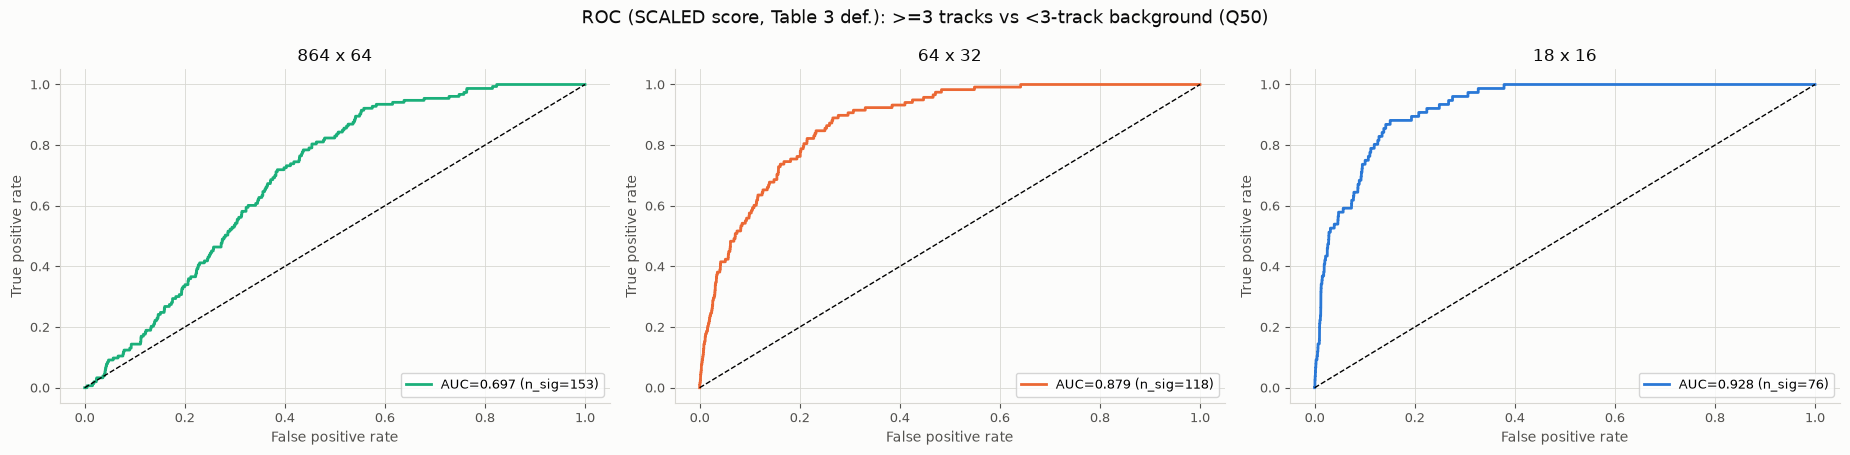

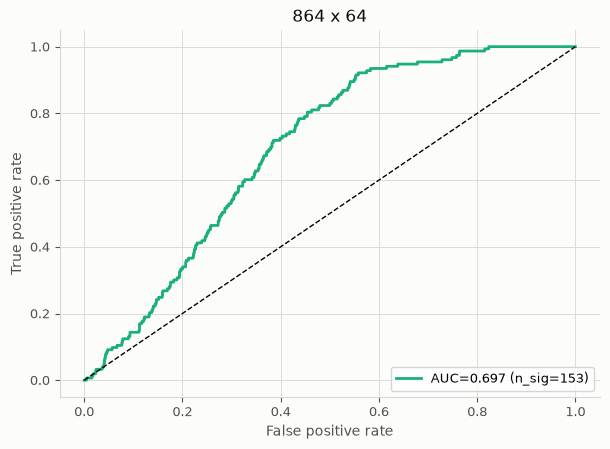

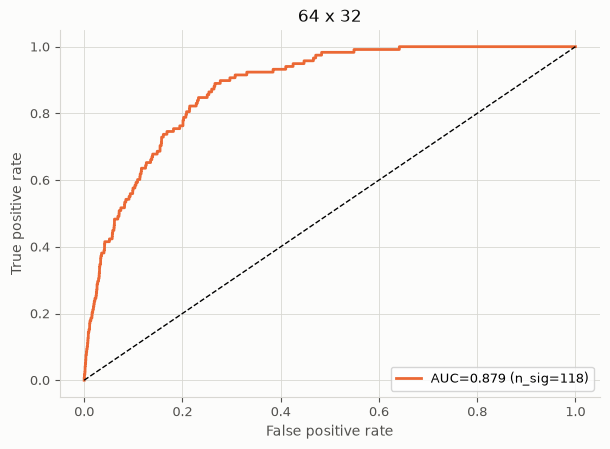

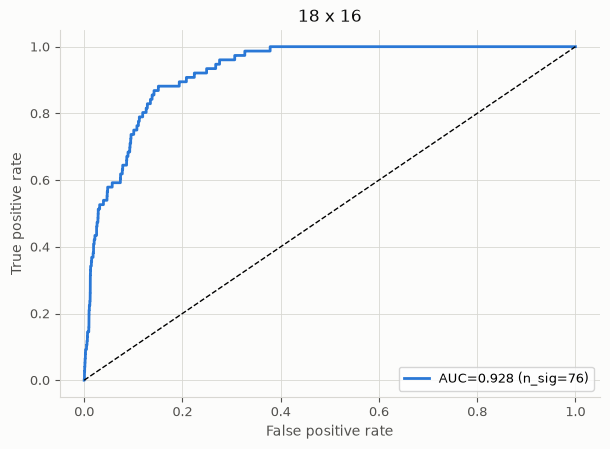

In [16]:
# SCALED anomaly score = anomaly_score / total pixel charge (paper section 3.1.5).
# Dividing out charge removes the trivial "more tracks -> more charge -> higher
# score" dependence, leaving sensitivity to TOPOLOGY -- the apples-to-apples-with
# -the-paper score. Same Table 3 signal definition (>=NREQ vs <NREQ-track). Reuses
# roc_results + roc_intensity from the ROC cell above (run it first); no re-scoring.
#
# WHAT IT SHOWS (this was NOT what we predicted): scaling LOWERS every AUC --
# confirming charge WAS a real confound in the regular score -- but it does NOT
# invert the size ordering. Small tiles stay best, and 864x64 drops the MOST
# (~0.82 -> ~0.68), meaning its regular-score edge was the most charge-driven,
# while 18x16 stays high (~0.92). So the gap vs the paper's Table 3 (large tiles
# best, 18x16 ~ chance) is NOT a charge artifact -- it is the Teacher-vs-Student
# difference: our full-precision AE keeps real topological sensitivity at 18x16
# (a >=3-track tile there is an extremely dense vertex, anomalous even per unit
# charge) that the paper's quantized Student loses.

def roc_panel_scaled(ax, s):
    Sc, Nt = roc_results[s]
    inten = roc_intensity[s]
    scaled = np.zeros_like(Sc, dtype=float)
    nz = inten > 0
    scaled[nz] = Sc[nz] / inten[nz]          # scaled anomaly score; empty tiles -> 0
    pos = Nt >= NREQ                          # background = everything else (< NREQ tracks)
    if pos.sum() == 0 or (~pos).sum() == 0:
        ax.text(0.5, 0.5, "insufficient signal/background", ha="center", va="center", color=INK2)
    else:
        fpr, tpr, auc = roc_curve_auc(pos, scaled)
        ax.plot(fpr, tpr, color=SIZE_COLOR[s], lw=2, label="AUC=%.3f (n_sig=%d)" % (auc, int(pos.sum())))
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("%d x %d" % s, color=INK, fontsize=12)
    ax.set_xlabel("False positive rate", color=INK2, fontsize=10)
    ax.set_ylabel("True positive rate", color=INK2, fontsize=10)
    ax.legend(loc="lower right", fontsize=9)

render_study(ROC_SIZES, roc_panel_scaled,
             "ROC (SCALED score, Table 3 def.): >=%d tracks vs <%d-track background (Q50)" % (NREQ, NREQ),
             panel_h=4.6)

## Track Clustering 

Run the following command on the `ubopendata` venv:

`conda run --no-capture-output -n ubopendata python main_project/MBOONE/tile_cluster.py`

then:


`conda run --no-capture-output -n ubopendata python main_project/MBOONE/tile_cluster.py pass2`

In order to crop and pad the tiles.


To downscale instead:

`conda run --no-capture-output -n ubopendata python main_project/MBOONE/tile_cluster.py pass3`




### 18x16 tile clustering

loaded cached truth labels: cluster_truth_labels_18x16.npy
TOTAL: 355041 clusters -> 323148 cosmic (91.0%), 31893 neutrino (9.0%)


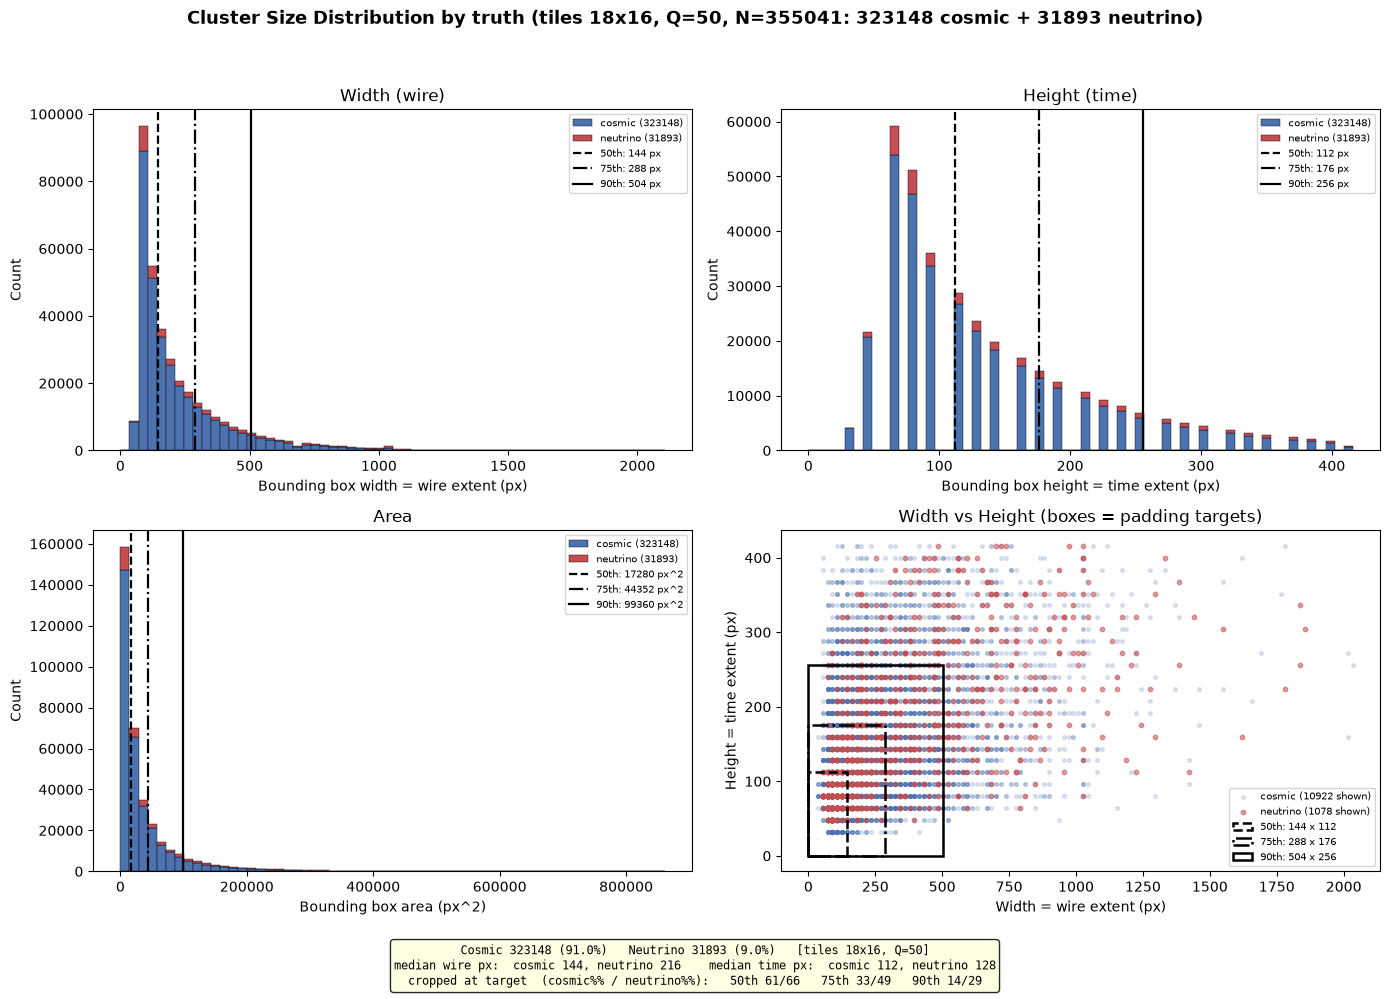

In [1]:
# Cluster size distribution, split by TRUTH into cosmic vs neutrino.
#
# The open samples are simulated neutrino overlaid on real beam-off cosmic data, so a
# hit is neutrino-induced exactly when it has a Geant4 association (edep_table/hit_id);
# cosmics carry no truth (same rule as the "neutrino signal vs charge cut" cell above).
# We build, per event, the set of 18x16 tiles containing a neutrino hit, and label a
# cluster "neutrino" when its tile bounding box overlaps one (else "cosmic").
# Labels are cached to a .npy so re-running the cell is instant.
#
# All four panels use ONE colour per class (blue = cosmic, red = neutrino), plus the
# 50th/75th/90th percentile lines (black) so you can see which padding target crops
# mostly cosmics and spares neutrinos.
import numpy as np, h5py
import matplotlib.pyplot as plt
from pathlib import Path

SIZE_TAG = "18x16"
TIME_FACTOR = 10                 # hit tick -> downsampled pixel (matches preprocessing)
PCTS = [(50, "--"), (75, "-."), (90, "-")]     # percentile lines (black, by linestyle)
COSMIC_C, NU_C = "#4C72B0", "#C44E52"          # consistent across all panels


def _find(cands):
    return next((p for p in cands if p.exists()), None)


D1 = _find([Path("main_project/MBOONE/clusterImages/clusters_raw_%s.h5" % SIZE_TAG),
            Path("clusterImages/clusters_raw_%s.h5" % SIZE_TAG)])
RAW_DIR = _find([Path("data/ubopendata"), Path("../../data/ubopendata")])
if D1 is None:
    raise FileNotFoundError("clusters_raw_%s.h5 not found; run tile_cluster.py pass 1 first" % SIZE_TAG)

f = h5py.File(D1, "r")
n = int(f.attrs["n_clusters"])
wb, tb = int(f.attrs["wire_blocks"]), int(f.attrs["time_blocks"])
sw, st = int(f.attrs["seg_wire"]), int(f.attrs["seg_time"])
Timg = int(f.attrs["image_time"])
widths = f["image_width_px"][:].astype(float)     # wire extent (px)
heights = f["image_height_px"][:].astype(float)   # time extent (px)
fid = f["source_file_id"][:]; evt = f["source_event_index"][:]
bbt = f["bbox_tile_coords"][:]
src_files = [s.decode() if isinstance(s, bytes) else s for s in f.attrs["source_files"]]
areas = widths * heights


def even_ceil(x):
    v = int(np.ceil(x)); return v + 1 if v % 2 else v


def build_nu_grids(raw_path, needed):
    """Per-event boolean (wb, tb) grids of tiles that contain a neutrino (Geant4) hit."""
    grids = {}
    with h5py.File(str(raw_path), "r") as rf:
        hs = rf["hit_table/event_id.seq_cnt"][:]; h_off = np.concatenate([[0], np.cumsum(hs[:, 1])])
        es = rf["edep_table/event_id.seq_cnt"][:]; e_off = np.concatenate([[0], np.cumsum(es[:, 1])])
        erow = {int(e): i for i, e in enumerate(es[:, 0])}
        plane = rf["hit_table/local_plane"][:, 0]; wire = rf["hit_table/local_wire"][:, 0]
        tim = rf["hit_table/local_time"][:, 0]; ehit = rf["edep_table/hit_id"][:, 0]
        for k, e in enumerate(hs[:, 0]):
            e = int(e)
            if e not in needed or e not in erow:
                continue
            a, b = int(h_off[k]), int(h_off[k + 1]); j = erow[e]
            ids = np.unique(ehit[int(e_off[j]):int(e_off[j + 1])])
            ids = ids[(ids >= 0) & (ids < b - a)]
            rows = a + ids; rows = rows[plane[rows] == 2]
            if rows.size == 0:
                continue
            w = wire[rows].astype(np.int64); t = (tim[rows] / TIME_FACTOR).astype(np.int64)
            ok = (w >= 0) & (w < wb * sw) & (t >= 0) & (t < Timg); w, t = w[ok], t[ok]
            if w.size:
                g = np.zeros((wb, tb), bool); g[w // sw, t // st] = True; grids[e] = g
    return grids


# ---- classify (cached) : is_nu[i] == cluster i contains neutrino-truth charge ----
cache = D1.parent / ("cluster_truth_labels_%s.npy" % SIZE_TAG)
if cache.exists() and np.load(cache).shape[0] == n:
    is_nu = np.load(cache)
    print("loaded cached truth labels: %s" % cache.name)
else:
    if RAW_DIR is None:
        raise FileNotFoundError("raw dir data/ubopendata not found (needed for truth labels)")
    print("classifying %d clusters against Geant4 truth (one-time; cached afterwards)..." % n)
    is_nu = np.zeros(n, bool)
    for k, sfile in enumerate(src_files):
        sel = np.nonzero(fid == k)[0]
        if sel.size == 0:
            continue
        raw = RAW_DIR / sfile.replace("_plane2_images", "")
        if not raw.exists():
            print("  file %d: %s missing -> its clusters stay 'cosmic'" % (k, raw.name)); continue
        grids = build_nu_grids(raw, set(int(x) for x in np.unique(evt[sel])))
        for ci in sel:
            g = grids.get(int(evt[ci]))
            if g is None:
                continue
            r0, r1, c0, c1 = bbt[ci]
            is_nu[ci] = bool(g[r0:r1 + 1, c0:c1 + 1].any())
        print("  file %02d: %d clusters, %d neutrino" % (k, sel.size, int(is_nu[sel].sum())))
    np.save(cache, is_nu)
    print("saved truth labels -> %s" % cache.name)
f.close()

n_nu = int(is_nu.sum()); n_cos = n - n_nu
print("TOTAL: %d clusters -> %d cosmic (%.1f%%), %d neutrino (%.1f%%)"
      % (n, n_cos, 100.0 * n_cos / n, n_nu, 100.0 * n_nu / n))


def split(a):
    return a[~is_nu], a[is_nu]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Cluster Size Distribution by truth (tiles %s, Q=50, N=%d: %d cosmic + %d neutrino)"
             % (SIZE_TAG, n, n_cos, n_nu), fontsize=13, fontweight="bold")


def stacked(ax, data, xlabel, title, unit="px"):
    cos, nu = split(data)
    bins = np.linspace(0, float(data.max()), 61)
    ax.hist([cos, nu], bins=bins, stacked=True, color=[COSMIC_C, NU_C],
            label=["cosmic (%d)" % cos.size, "neutrino (%d)" % nu.size],
            edgecolor="black", linewidth=0.3)
    for pct, lstyle in PCTS:
        v = np.percentile(data, pct)
        ax.axvline(v, color="black", linestyle=lstyle, linewidth=1.6, label="%dth: %.0f %s" % (pct, v, unit))
    ax.set_xlabel(xlabel); ax.set_ylabel("Count"); ax.set_title(title); ax.legend(fontsize=7)


stacked(axes[0, 0], widths, "Bounding box width = wire extent (px)", "Width (wire)")
stacked(axes[0, 1], heights, "Bounding box height = time extent (px)", "Height (time)")
stacked(axes[1, 0], areas, "Bounding box area (px^2)", "Area", unit="px^2")

# Panel 4: width vs height, coloured by class, with the 50/75/90 target boxes.
sc = axes[1, 1]
rng = np.random.default_rng(0)
BUDGET = 12000        # points shown, split by the TRUE class fractions (honest density)


def subs(mask, frac):
    ix = np.nonzero(mask)[0]
    k = min(ix.size, int(round(BUDGET * frac)))
    return rng.choice(ix, k, replace=False) if ix.size > k else ix


cos_ix = subs(~is_nu, n_cos / n)
nu_ix = subs(is_nu, n_nu / n)
sc.scatter(widths[cos_ix], heights[cos_ix], s=7, alpha=0.18, color=COSMIC_C,
           label="cosmic (%d shown)" % cos_ix.size)
sc.scatter(widths[nu_ix], heights[nu_ix], s=10, alpha=0.55, color=NU_C,
           label="neutrino (%d shown)" % nu_ix.size)
for pct, lstyle in PCTS:
    w, h = np.percentile(widths, pct), np.percentile(heights, pct)
    sc.add_patch(plt.Rectangle((0, 0), w, h, fill=False, edgecolor="black", linestyle=lstyle,
                               linewidth=1.8, label="%dth: %.0f x %.0f" % (pct, w, h)))
sc.set_xlabel("Width = wire extent (px)"); sc.set_ylabel("Height = time extent (px)")
sc.set_title("Width vs Height (boxes = padding targets)"); sc.legend(fontsize=7)

# stats box: per-class medians + the key number -- % of each class CROPPED at each target
def cropped_frac(mask, pct):
    tw, tt = even_ceil(np.percentile(widths, pct)), even_ceil(np.percentile(heights, pct))
    over = (widths[mask] > tw) | (heights[mask] > tt)
    return 100.0 * over.mean() if mask.sum() else 0.0


lines = ["Cosmic %d (%.1f%%)   Neutrino %d (%.1f%%)   [tiles %s, Q=50]"
         % (n_cos, 100.0 * n_cos / n, n_nu, 100.0 * n_nu / n, SIZE_TAG),
         "median wire px:  cosmic %.0f, neutrino %.0f    median time px:  cosmic %.0f, neutrino %.0f"
         % (np.median(widths[~is_nu]), np.median(widths[is_nu]),
            np.median(heights[~is_nu]), np.median(heights[is_nu])),
         "cropped at target  (cosmic%% / neutrino%%):   "
         + "   ".join("%dth %.0f/%.0f" % (p, cropped_frac(~is_nu, p), cropped_frac(is_nu, p))
                      for p, _ in PCTS)]
fig.text(0.5, 0.005, "\n".join(lines), ha="center", fontsize=8.5, family="monospace",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.85))
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

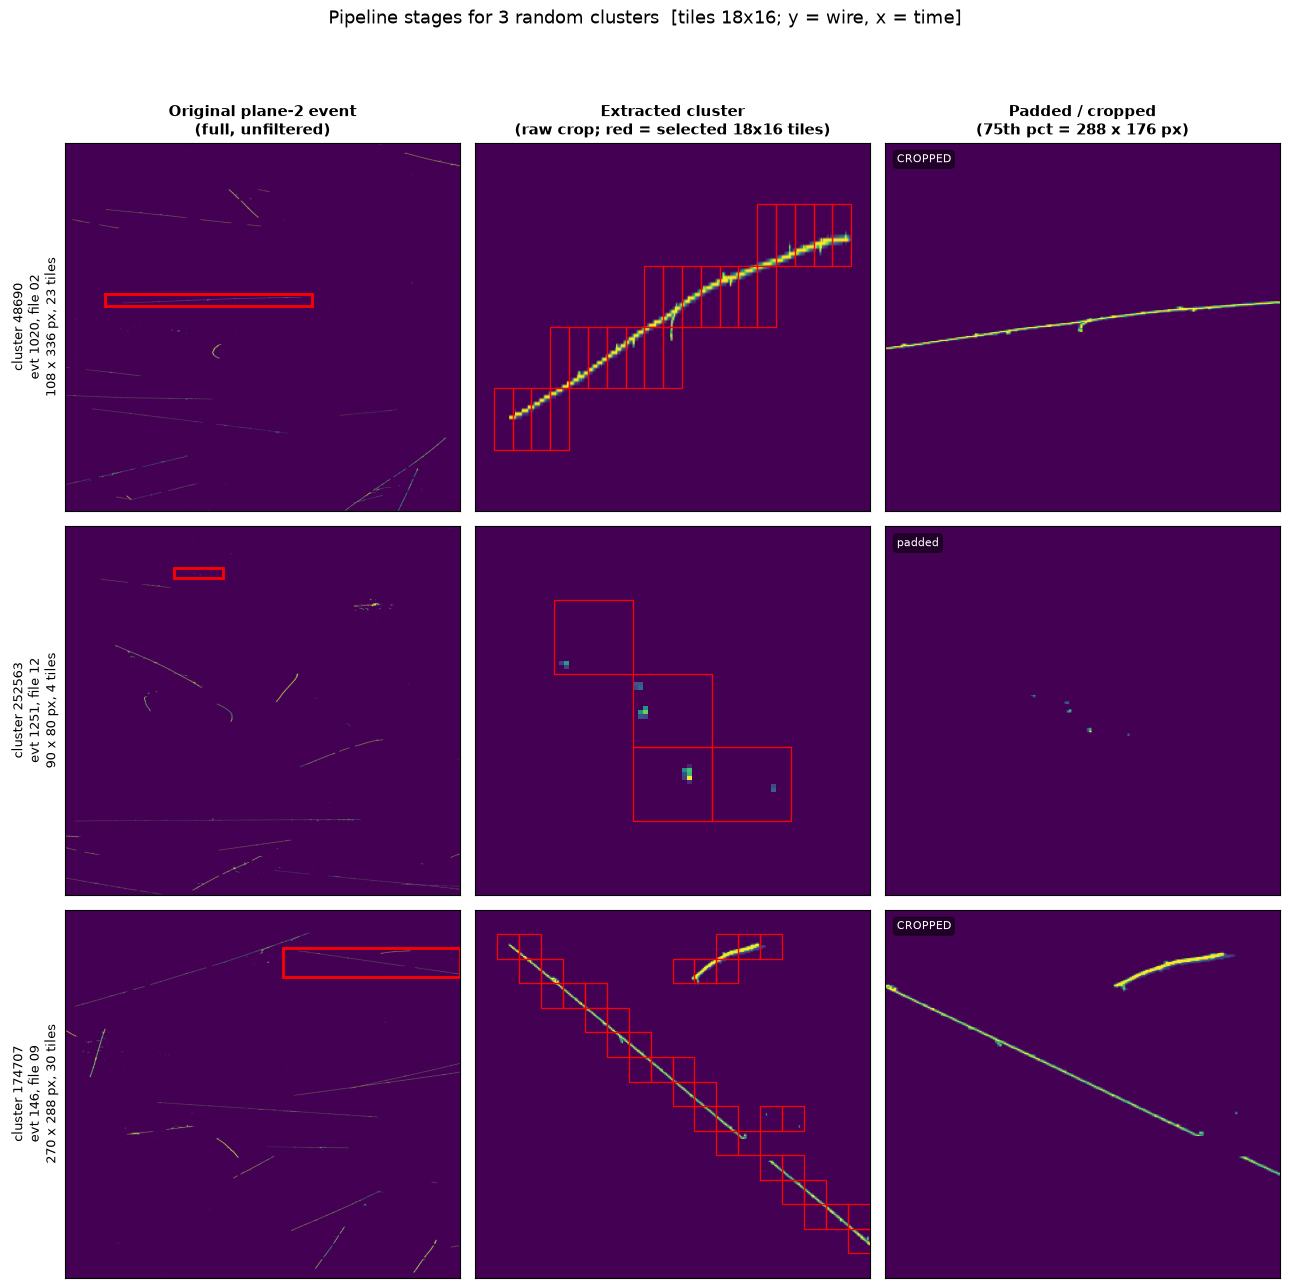

In [18]:
# Pipeline stages for a few random clusters, one cluster per ROW, three COLUMNS:
#   1. the ORIGINAL full plane-2 event (raw input, no empty-removal / clustering;
#      red box = where this cluster sits in the event),
#   2. the RAW extracted cluster crop, with the 18x16 tiles the clustering SELECTED
#      (charge >= 50) outlined in red -- i.e. the tiles the king-move step grouped,
#   3. that crop padded (or center-cropped) to the 75th-percentile target -- the
#      fixed size the autoencoder would see.
import numpy as np, h5py
import matplotlib.pyplot as plt
from pathlib import Path

SIZE_TAG = "18x16"
N_ROWS = 3            # number of random clusters (rows)
TARGET_PCT = 75       # column-3 padding target percentile (matches clusters_padded_75_*)
# rng = np.random.default_rng(0)   # <- set a seed here for a reproducible pick
rng = np.random.default_rng()


def _find(cands):
    for p in cands:
        if p.exists():
            return p
    return None


D1 = _find([Path("main_project/MBOONE/clusterImages/clusters_raw_%s.h5" % SIZE_TAG),
            Path("clusterImages/clusters_raw_%s.h5" % SIZE_TAG)])
PROC_DIR = _find([Path("data/ubopendata/processed_npy"),
                  Path("../../data/ubopendata/processed_npy")])
if D1 is None or PROC_DIR is None:
    raise FileNotFoundError("need clusters_raw_%s.h5 (pass 1) and data/ubopendata/processed_npy/" % SIZE_TAG)


def apply_cuts(img, cut, sat):
    out = np.asarray(img, np.float32).copy()
    out[out < cut] = 0; out[out > sat] = sat
    return out


def even_ceil(x):
    v = int(np.ceil(x))
    return v + 1 if v % 2 else v


def pad_to_target(image, tw, tt):
    h, w = image.shape
    if h > tw or w > tt:                       # bigger than target -> center-crop
        s0 = max(0, (h - tw) // 2); s1 = max(0, (w - tt) // 2)
        image = image[s0:s0 + min(h, tw), s1:s1 + min(w, tt)]; h, w = image.shape
    out = np.zeros((tw, tt), image.dtype)      # smaller -> center zero-pad
    out[(tw - h) // 2:(tw - h) // 2 + h, (tt - w) // 2:(tt - w) // 2 + w] = image
    return out


f = h5py.File(D1, "r")
off = f["image_offsets"][:]
Wpx, Hpx = f["image_width_px"][:], f["image_height_px"][:]     # wire, time extents
n_tiles = f["n_tiles"][:]
bpx = f["bbox_pixel_coords"]; ev = f["source_event_index"]; fid = f["source_file_id"]
src_files = [s.decode() if isinstance(s, bytes) else s for s in f.attrs["source_files"]]
cutoff = float(f.attrs.get("cutoff", 10)); saturation = float(f.attrs.get("saturation", 100))
sw = int(f.attrs["seg_wire"]); st = int(f.attrs["seg_time"])           # tile size (18 x 16)
charge_min = float(f.attrs.get("charge_min", 50.0))
n = int(f.attrs["n_clusters"])

tw = even_ceil(np.percentile(Wpx, TARGET_PCT))
tt = even_ceil(np.percentile(Hpx, TARGET_PCT))


def raw_crop(i):
    return f["image_data"][int(off[i]):int(off[i + 1])].reshape(int(Wpx[i]), int(Hpx[i]))


def outline_selected_tiles(ax, img, color="red", lw=0.9):
    """Red box around every sw x st tile whose summed charge >= charge_min."""
    k, m = img.shape[0] // sw, img.shape[1] // st
    tilechg = img.reshape(k, sw, m, st).sum(axis=(1, 3))
    for iv, ih in zip(*np.nonzero(tilechg >= charge_min)):
        ax.add_patch(plt.Rectangle((ih * st - 0.5, iv * sw - 0.5), st, sw,
                                   fill=False, edgecolor=color, linewidth=lw))


idx = rng.choice(n, N_ROWS, replace=False)
col_titles = ["Original plane-2 event\n(full, unfiltered)",
              "Extracted cluster\n(raw crop; red = selected 18x16 tiles)",
              "Padded / cropped\n(%dth pct = %d x %d px)" % (TARGET_PCT, tw, tt)]

fig, axes = plt.subplots(N_ROWS, 3, figsize=(13, 4.3 * N_ROWS))
axes = np.atleast_2d(axes)
_cache = {}
for r, i in enumerate(idx):
    fi, e = int(fid[i]), int(ev[i])
    if fi not in _cache:
        _cache[fi] = h5py.File(PROC_DIR / src_files[fi], "r")
    full = apply_cuts(_cache[fi]["image"][e], cutoff, saturation)      # (wire, time)
    crop = raw_crop(i)
    padded = pad_to_target(crop, tw, tt)
    py1, py2, px1, px2 = [int(v) for v in bpx[i]]                       # wire_lo,hi, time_lo,hi

    axes[r, 0].imshow(full, cmap="viridis", origin="lower", aspect="auto")     # x=time, y=wire
    axes[r, 0].add_patch(plt.Rectangle((px1, py1), px2 - px1, py2 - py1,
                                       fill=False, edgecolor="red", linewidth=2))
    axes[r, 0].set_ylabel("cluster %d\nevt %d, file %02d\n%d x %d px, %d tiles"
                          % (i, e, fi, int(Wpx[i]), int(Hpx[i]), int(n_tiles[i])), fontsize=9)
    axes[r, 1].imshow(crop, cmap="viridis", origin="lower", aspect="auto")
    outline_selected_tiles(axes[r, 1], crop)                            # 18x16 tile grid
    axes[r, 2].imshow(padded, cmap="viridis", origin="lower", aspect="auto")
    tag = "CROPPED" if (crop.shape[0] > tw or crop.shape[1] > tt) else "padded"
    axes[r, 2].text(0.03, 0.97, tag, transform=axes[r, 2].transAxes, va="top", ha="left",
                    fontsize=8, color="white", bbox=dict(boxstyle="round", facecolor="black", alpha=0.5))
    for c in range(3):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

for c, t in enumerate(col_titles):
    axes[0, c].set_title(t, fontsize=11, fontweight="bold")

fig.suptitle("Pipeline stages for %d random clusters  [tiles %s; y = wire, x = time]"
             % (N_ROWS, SIZE_TAG), fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

for fh in _cache.values():
    fh.close()
f.close()

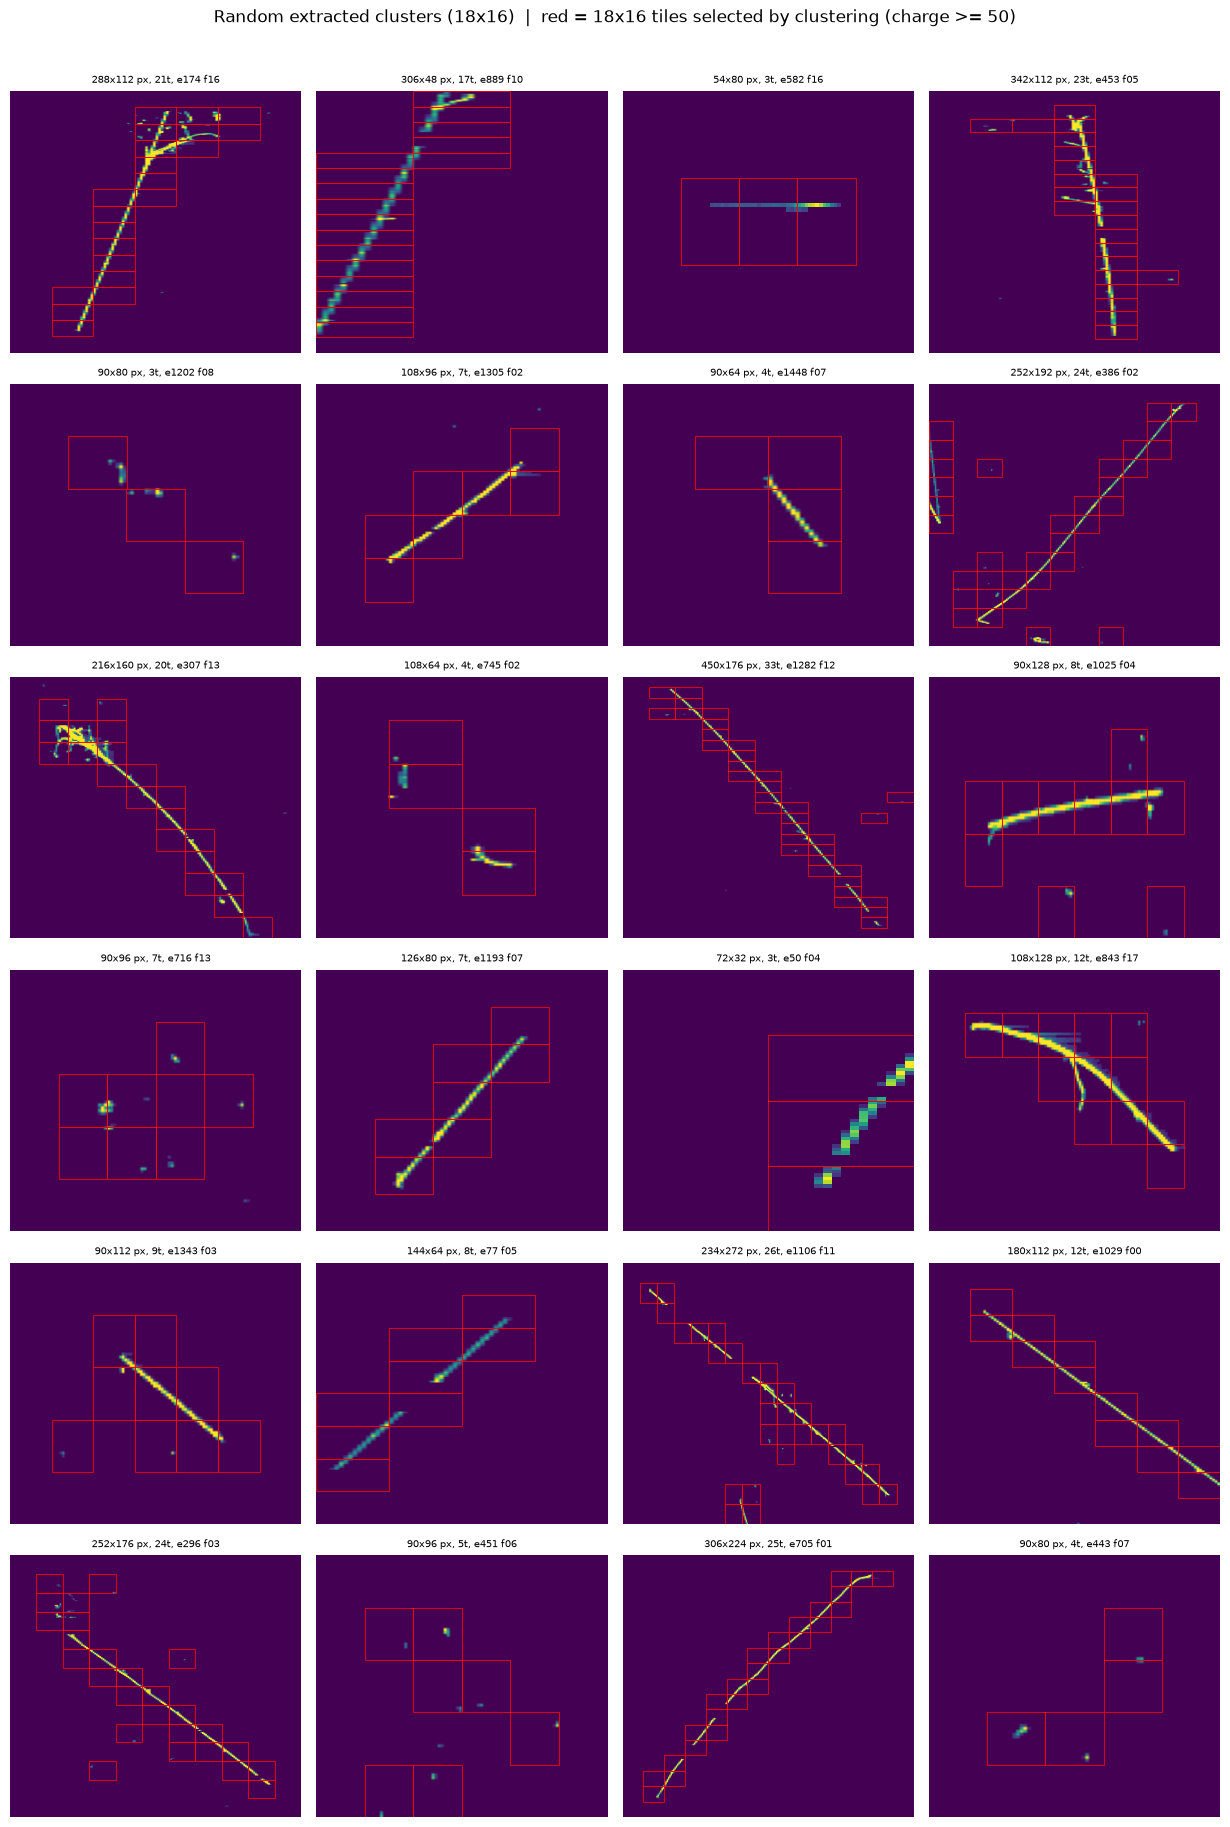

In [19]:
# 24 random extracted clusters (like tile_cluster.py's D3 sample PNG) straight from
# D1 -- no need to rerun the script. Each 18x16 tile the clustering SELECTED (summed
# charge >= 50) is outlined in red; empty / padding tiles get no box, so the red grid
# shows exactly which tiles the king-move step grouped into the cluster.
import numpy as np, h5py
import matplotlib.pyplot as plt
from pathlib import Path

SIZE_TAG = "18x16"
N_SHOW = 24
NCOL = 4
# rng = np.random.default_rng(0)   # <- set a seed here for a reproducible pick
rng = np.random.default_rng()

_cands = [Path("main_project/MBOONE/clusterImages") / ("clusters_raw_%s.h5" % SIZE_TAG),
          Path("clusterImages") / ("clusters_raw_%s.h5" % SIZE_TAG)]
D1 = next((p for p in _cands if p.exists()), None)
if D1 is None:
    raise FileNotFoundError("clusters_raw_%s.h5 not found; run tile_cluster.py pass 1 first" % SIZE_TAG)

f = h5py.File(D1, "r")
sw = int(f.attrs["seg_wire"]); st = int(f.attrs["seg_time"])
charge_min = float(f.attrs.get("charge_min", 50.0))
off = f["image_offsets"][:]
Wpx = f["image_width_px"][:]; Hpx = f["image_height_px"][:]
ntiles = f["n_tiles"][:]; ev = f["source_event_index"][:]; fid = f["source_file_id"][:]
n = int(f.attrs["n_clusters"])


def crop(i):
    return f["image_data"][int(off[i]):int(off[i + 1])].reshape(int(Wpx[i]), int(Hpx[i]))


def outline_selected_tiles(ax, img, color="red", lw=0.6):
    """Red box around every sw x st tile whose summed charge >= charge_min."""
    k, m = img.shape[0] // sw, img.shape[1] // st
    tilechg = img.reshape(k, sw, m, st).sum(axis=(1, 3))
    for iv, ih in zip(*np.nonzero(tilechg >= charge_min)):
        ax.add_patch(plt.Rectangle((ih * st - 0.5, iv * sw - 0.5), st, sw,
                                   fill=False, edgecolor=color, linewidth=lw))


idx = rng.choice(n, N_SHOW, replace=False)
nrow = int(np.ceil(N_SHOW / NCOL))
fig, axes = plt.subplots(nrow, NCOL, figsize=(3.1 * NCOL, 3.1 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.axis("off")
for ax, i in zip(axes, idx):
    img = crop(i)
    ax.imshow(img, cmap="viridis", origin="lower", aspect="auto")
    outline_selected_tiles(ax, img)
    ax.set_title("%dx%d px, %dt, e%d f%02d" % (int(Wpx[i]), int(Hpx[i]), int(ntiles[i]),
                                               int(ev[i]), int(fid[i])), fontsize=7)
fig.suptitle("Random extracted clusters (%s)  |  red = 18x16 tiles selected by clustering (charge >= %d)"
             % (SIZE_TAG, int(charge_min)), fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
f.close()

## 18x16 tile clustering training

To run command:

` conda run --no-capture-output -n ubopendata python main_project/MBOONE/Clustering_Training.py --percentile 50,75 --threads 6 --priority low --batch-size 64`

Only done AFTER running the tile cluster command above (all data should be stored in clusterImages folder). Ajdust percentile as needed.

If using the downscaled version, run:

`conda run --no-capture-output -n ubopendata python main_project/MBOONE/Clustering_Training.py --dataset downscale --percentile 50,75 --priority low --batch-size 64`

### Dataset switch (crop vs downscale)

In [10]:
# ===== 18x16 cluster-training evaluation -- SECTION CONFIG (set DATASET here) =====
# ONE switch for every eval cell below.
#   "crop"      -> pass-2 files clusters_padded_<pct>_18x16.h5
#                  (oversized clusters CENTER-CROPPED; all clusters kept)
#   "downscale" -> pass-3 files clusters_padded_downscaled_<pct>_18x16.h5
#                  (oversized clusters DOWNSCALED to fit; <=4-tile blips dropped)
# Any other value raises immediately.  Crop and downscale use separate model folders and
# score caches, so flipping this never overwrites the other variant's results.  Run this
# cell, then the cells below top-to-bottom.  (Must match Clustering_Training.py's --dataset.)
import numpy as np, h5py
import matplotlib.pyplot as plt
from pathlib import Path

DATASET = "crop"          # <-- "crop" or "downscale"

_VARIANT = {"crop": "", "downscale": "downscaled_"}
if DATASET not in _VARIANT:
    raise ValueError("DATASET must be 'crop' or 'downscale', got %r" % (DATASET,))
VTAG = _VARIANT[DATASET]                        # "" (crop) or "downscaled_"

PCTS = [50, 75]
TILE_TAG = "18x16"
SIZES = {50: (144, 112), 75: (288, 176)}        # padded target (same for both variants)
TOTAL_IMAGES, SEED = 60000, 42                  # MUST match Clustering_Training.py
COSMIC_C, NU_C = "#4C72B0", "#C44E52"
INK, INK2 = "#0b0b0b", "#52514e"


def _find(cands):
    return next((p for p in cands if p.exists()), None)


CIMG = _find([Path("clusterImages"), Path("main_project/MBOONE/clusterImages")])
SAVE = _find([Path("savedModel"), Path("main_project/MBOONE/savedModel")])
RAW_DIR = _find([Path("../../data/ubopendata"), Path("data/ubopendata")])

# Variant-aware paths (crop keeps the original unprefixed names).
def padded_path(pct):   return CIMG / ("clusters_padded_%s%d_%s.h5" % (VTAG, pct, TILE_TAG))
def model_dir(pct):     return SAVE / ("cluster_%s%d_%s" % (VTAG, pct, TILE_TAG))
def model_path(pct):    return model_dir(pct) / ("unsupervised_cluster_%s%d_%s.h5" % (VTAG, pct, TILE_TAG))
def history_path(pct):  return model_dir(pct) / ("unsupervised_cluster_%s%d_%s_history.csv" % (VTAG, pct, TILE_TAG))
def score_cache(pct):   return CIMG / ("eval_scores_%s%d_%s.npz" % (VTAG, pct, TILE_TAG))
def ntracks_cache():    return CIMG / ("cluster_ntracks_%stest_%s.npy" % (VTAG, TILE_TAG))


def test_rows(n_total, total=TOTAL_IMAGES, seed=SEED):
    """The exact held-out test rows Clustering_Training uses (sorted -> valid h5py index)."""
    idx = np.arange(n_total)
    np.random.default_rng(seed).shuffle(idx)
    idx = idx[:min(total, n_total)]
    m = len(idx)
    n_tr = int(round(0.5 * m)); n_va = int(round(0.1 * m))
    return np.sort(idx[n_tr + n_va:])                     # test = last 40%


def roc_curve_auc(y, sc):
    """ROC curve + trapezoidal AUC in pure numpy (this env's sklearn DLLs are broken)."""
    y = np.asarray(y).astype(int); sc = np.asarray(sc, float)
    order = np.argsort(-sc); y = y[order]
    P, N = int(y.sum()), len(y) - int(y.sum())
    if P == 0 or N == 0:
        return np.array([0, 1]), np.array([0, 1]), float("nan")
    tpr = np.concatenate([[0.0], np.cumsum(y) / P]); fpr = np.concatenate([[0.0], np.cumsum(1 - y) / N])
    return fpr, tpr, float(np.trapz(tpr, fpr))


print("DATASET = %r  ->  %s , %s" % (DATASET, padded_path(50).name, padded_path(75).name))

DATASET = 'crop'  ->  clusters_padded_50_18x16.h5 , clusters_padded_75_18x16.h5


### Loss

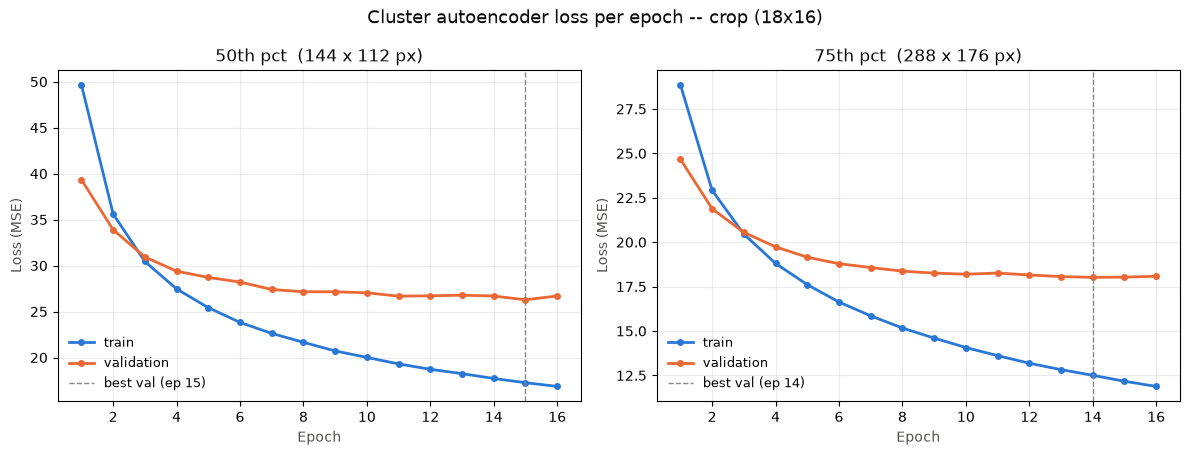

In [2]:
# Training vs validation loss (MSE) per epoch for the 18x16 CLUSTER autoencoders of the
# chosen DATASET (config cell above), one panel per percentile, from the *_history.csv
# files.  (For "downscale" you must have trained that variant first:
#   python Clustering_Training.py --dataset downscale --percentile 50,75 )
fig, axes = plt.subplots(1, len(PCTS), figsize=(6 * len(PCTS), 4.6), squeeze=False)
for ax, pct in zip(axes[0], PCTS):
    d = np.loadtxt(str(history_path(pct)), delimiter=",", skiprows=1)      # epoch, loss, val_loss
    ep = d[:, 0] + 1
    ax.plot(ep, d[:, 1], color="#2a78d6", lw=2, marker="o", ms=4, label="train")
    ax.plot(ep, d[:, 2], color="#eb6834", lw=2, marker="o", ms=4, label="validation")
    best = int(d[np.argmin(d[:, 2]), 0]) + 1
    ax.axvline(best, color="#888", ls="--", lw=1, label="best val (ep %d)" % best)
    ax.set_title("%dth pct  (%d x %d px)" % (pct, *SIZES[pct]), color=INK, fontsize=12)
    ax.set_xlabel("Epoch", color=INK2); ax.set_ylabel("Loss (MSE)", color=INK2)
    ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=9)
fig.suptitle("Cluster autoencoder loss per epoch -- %s (18x16)" % DATASET, fontsize=13, color=INK)
fig.tight_layout()
plt.show()

### Anomaly Score histogram 

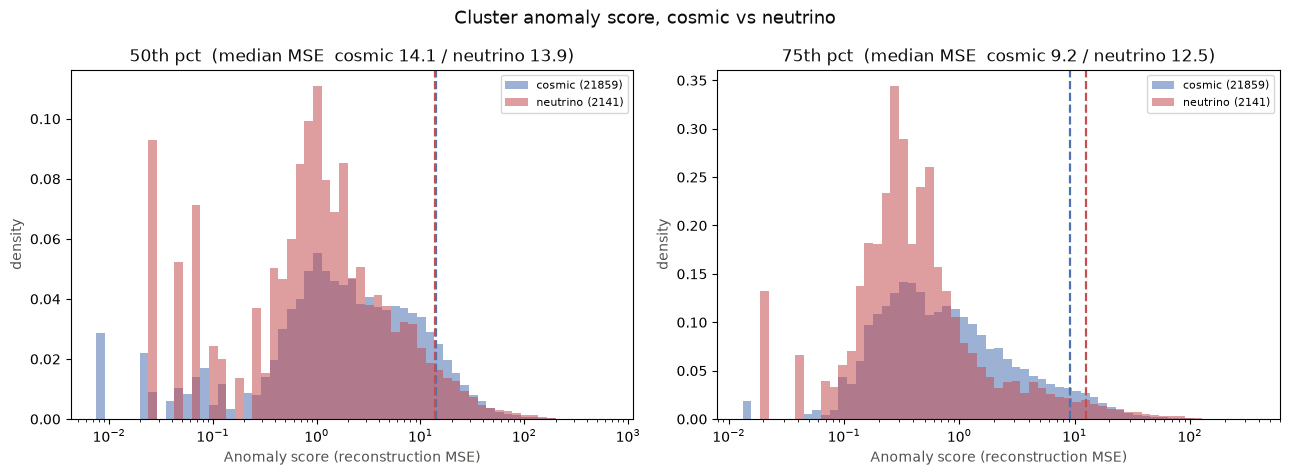

In [18]:
# Anomaly score = per-cluster reconstruction MSE.  Loads the models for the chosen DATASET
# (config cell), scores the held-out TEST clusters for both percentiles (cached to
# eval_scores_<variant><pct>_18x16.npz), and plots the score split by TRUTH: cosmic (blue)
# vs neutrino (red).  Truth is mapped through the file's raw_index for "downscale" (its rows
# are FILTERED, so positional indexing would MISMAP); for "crop", rows == raw order.  Defines
# cluster_model + CL_EVAL that the Input / ROC / multiplicity cells below all reuse.
#
# NOTE: keras.models.load_model crashes on this env's h5py>=3 (str attrs have no .decode),
# so we rebuild the (identical) architecture and read the weights by hand.
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")      # CPU only
from tensorflow import keras
try:
    from Clustering_Training import build_unsupervised
except ImportError:
    for _p in (".", "main_project/MBOONE"):
        if _p not in sys.path:
            sys.path.insert(0, _p)
    from Clustering_Training import build_unsupervised

CHUNK = 512                               # test clusters read/scored per HDF5 chunk
PB = {50: 256, 75: 64}                    # predict batch size per percentile


def _load_weights_h5(model, path):
    """Read weights straight from a full-model .h5 and set_weights (bypasses keras's
    HDF5 loader, which crashes on h5py>=3)."""
    with h5py.File(str(path), "r") as f:
        g = f["model_weights"]
        flat = []
        for layer in model.layers:
            if not layer.weights:
                continue
            lg = g[layer.name]
            names = [n.decode() if isinstance(n, (bytes, bytearray)) else n
                     for n in lg.attrs["weight_names"]]
            flat += [np.asarray(lg[n]) for n in names]
    model.set_weights(flat)
    return model


def cluster_model(pct):
    m = build_unsupervised((*SIZES[pct], 1))
    return _load_weights_h5(m, model_path(pct))


def cluster_eval(pct):
    """dict(raw, inten, is_nu, idx, raw_rows) of test-cluster scores; cached to npz.

    idx      = rows into THIS dataset's padded `images`.
    raw_rows = the corresponding rows in clusters_raw (== idx for crop; via the file's
               raw_index for downscale), used to look up truth by RAW-cluster order.
    """
    cache = score_cache(pct)
    if cache.exists():
        d = dict(np.load(cache))
        d.setdefault("raw_rows", d["idx"])            # old crop caches: raw_rows == idx
        return d
    is_nu_full = np.load(CIMG / ("cluster_truth_labels_%s.npy" % TILE_TAG))   # indexed by RAW order
    f = h5py.File(str(padded_path(pct)), "r")
    imgs = f["images"]
    te = test_rows(imgs.shape[0])
    raw_rows = f["metadata/raw_index"][:][te] if DATASET == "downscale" else te
    labels = is_nu_full[raw_rows]
    model = cluster_model(pct)
    raw, inten = [], []
    for s in range(0, len(te), CHUNK):
        X = imgs[te[s:s + CHUNK]][..., None].astype("float32")
        rec = model.predict(X, batch_size=PB[pct], verbose=0)
        raw.append(np.mean((X - rec) ** 2, axis=(1, 2, 3)))
        inten.append(X.sum(axis=(1, 2, 3)))
    f.close(); keras.backend.clear_session()
    out = dict(raw=np.concatenate(raw), inten=np.concatenate(inten),
               is_nu=labels, idx=te, raw_rows=raw_rows)
    np.savez(cache, **out); print("cached %s" % cache.name)
    return out


CL_EVAL = {p: cluster_eval(p) for p in PCTS}     # <-- shared by the Input / ROC / multiplicity cells

fig, axes = plt.subplots(1, len(PCTS), figsize=(6.5 * len(PCTS), 4.8), squeeze=False)
for ax, pct in zip(axes[0], PCTS):
    raw = CL_EVAL[pct]["raw"]; isnu = CL_EVAL[pct]["is_nu"].astype(bool)
    cos, nu = raw[~isnu], raw[isnu]
    lo = max(float(raw[raw > 0].min()), 1e-3)
    bins = np.logspace(np.log10(lo), np.log10(float(raw.max())), 60)
    ax.hist(cos, bins=bins, color=COSMIC_C, alpha=0.55, density=True, label="cosmic (%d)" % cos.size)
    ax.hist(nu, bins=bins, color=NU_C, alpha=0.55, density=True, label="neutrino (%d)" % nu.size)
    ax.axvline(np.median(cos), color=COSMIC_C, ls="--", lw=1.6)
    ax.axvline(np.median(nu), color=NU_C, ls="--", lw=1.6)
    ax.set_xscale("log")
    ax.set_title("%dth pct  (median MSE  cosmic %.1f / neutrino %.1f)"
                 % (pct, np.median(cos), np.median(nu)), color=INK, fontsize=12)
    ax.set_xlabel("Anomaly score (reconstruction MSE)", color=INK2)
    ax.set_ylabel("density", color=INK2); ax.legend(fontsize=8)
fig.suptitle("Cluster anomaly score, cosmic vs neutrino",
             fontsize=13, color=INK)
fig.tight_layout()
plt.show()

loaded cached charge fractions: cluster_nu_chargefrac_18x16.npy
50th pct: 14619/24000 test clusters were cropped (f covers the full bbox regardless)
75th pct: 8292/24000 test clusters were cropped (f covers the full bbox regardless)


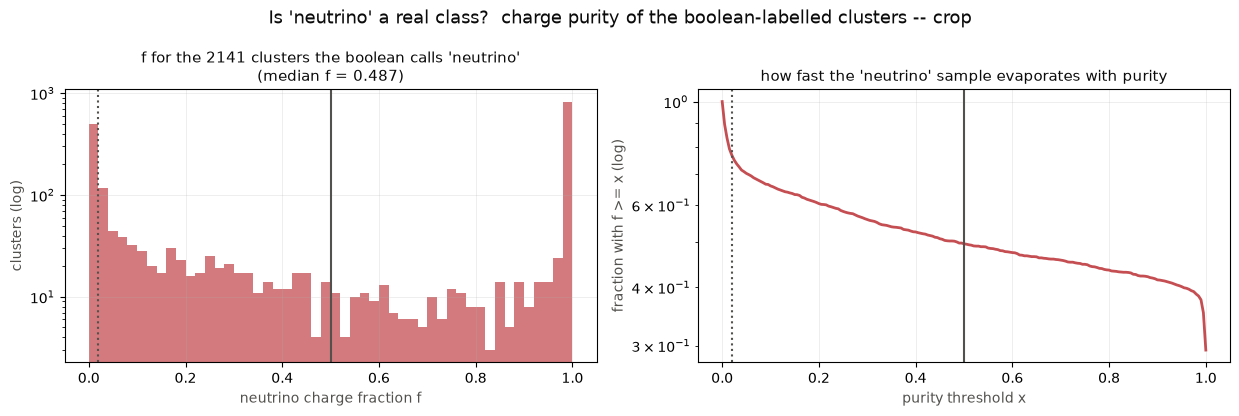


of the 2141 boolean-'neutrino' test clusters: 23.3% have f < 0.02 (i.e. essentially cosmic), 49.6% have f >= 0.50


C:\Users\aidan\AppData\Local\Temp\ipykernel_48364\3814592617.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return fpr, tpr, float(np.trapz(tpr, fpr))


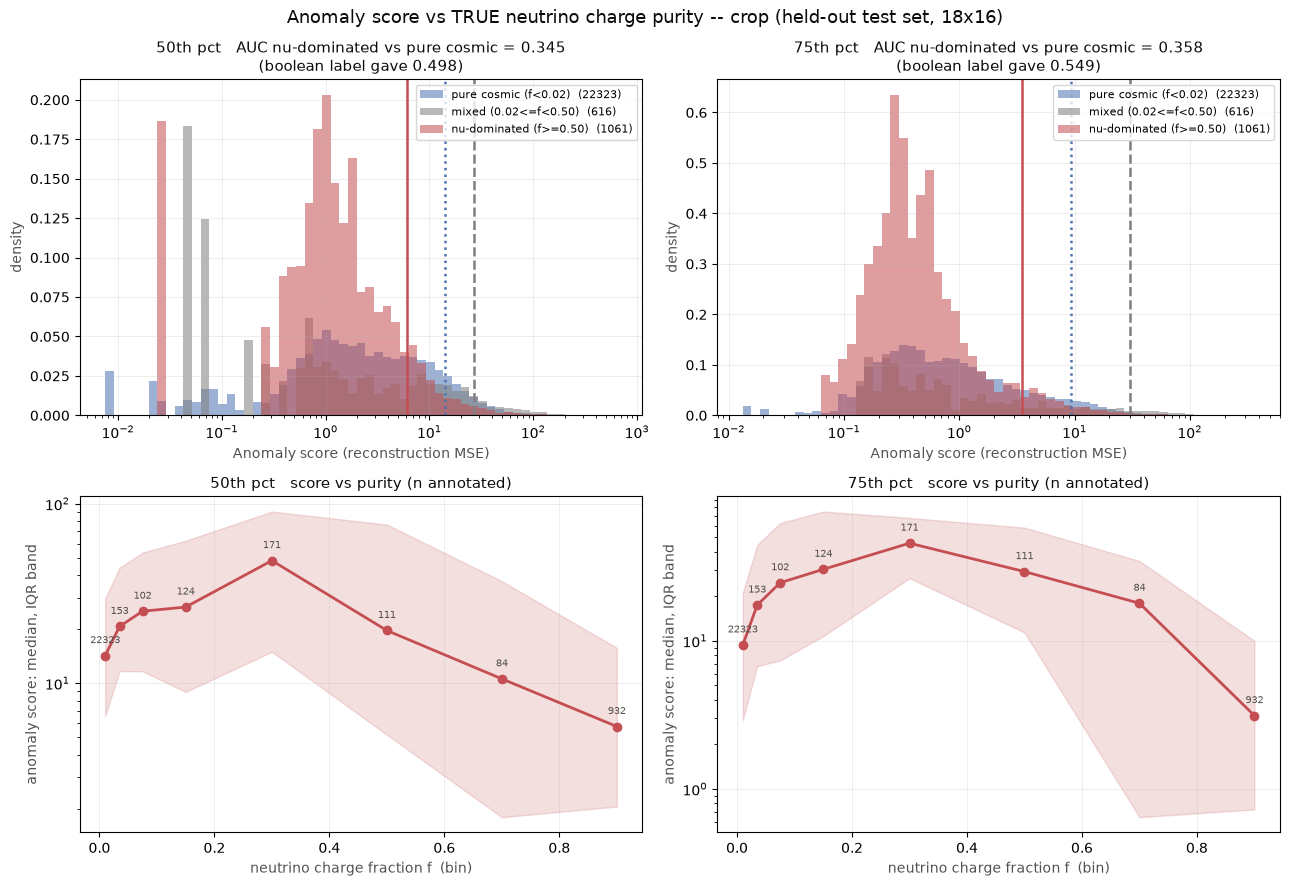

In [7]:
# ---------- Neutrino CHARGE FRACTION per cluster: is the flat histogram above a LABEL bug? ----------
# The plot above splits clusters by the BOOLEAN is_nu built in the "cluster size by truth" cell:
#   is_nu = "the cluster's TILE bounding box overlaps some tile holding >=1 Geant4 hit".
# In an overlay sample that flag fires for a mostly-cosmic cluster that merely passes near a nu
# vertex, so the red curve is largely cosmics -- and the two distributions must sit on top of each
# other whether or not the autoencoder can see neutrinos.  This cell replaces the boolean with a
# CONTINUOUS purity and re-reads the SAME scores against it:
#
#     f = (neutrino-attributable charge in the cluster image) / (total charge in the cluster image)
#
# Definition notes:
#   * Denominator is the cluster's PIXEL bounding box (bbox_pixel_coords).  extract_cluster_image()
#     crops that rectangle WITHOUT masking out non-cluster tiles, so the rectangle IS what the model
#     is fed -- f is literally "what fraction of what the AE sees is neutrino".
#   * Per hit: charge = |hit_table/integral|.  Its neutrino share = sum of edep_table/energy_fraction
#     over that hit's g4 rows (clipped to 1).  Cosmics are real beam-off data with no edep rows, so
#     they get share 0 automatically -- same truth rule as build_nu_grids(), just charge-weighted and
#     at PIXEL rather than TILE granularity.
#   * edep_table/hit_id is EVENT-LOCAL (same convention as build_nu_grids above).
#   * Cached by RAW cluster order, like cluster_truth_labels_*.npy, so CL_EVAL["raw_rows"] indexes it.
# Requires the Anomaly cell above (CL_EVAL) and the raw cluster file clusters_raw_<TILE_TAG>.h5.
TIME_FACTOR = 10                 # hit tick -> pixel (matches preprocessing)
TRACE, PURE = 0.02, 0.50         # f < TRACE -> pure cosmic;  f >= PURE -> neutrino-dominated
MIXED_C = "#7F7F7F"              # neutral midpoint between COSMIC_C (blue) and NU_C (red)

nuf_cache = CIMG / ("cluster_nu_chargefrac_%s.npy" % TILE_TAG)
raw_cluster_path = CIMG / ("clusters_raw_%s.h5" % TILE_TAG)


def build_nu_chargefrac():
    """f per RAW cluster = neutrino charge / total charge inside its pixel bbox.  NaN = no truth file."""
    with h5py.File(str(raw_cluster_path), "r") as cf:
        bbp = cf["bbox_pixel_coords"][:].astype(np.int64)      # (py1, py2, px1, px2) = wire lo/hi, time lo/hi
        cfid = cf["source_file_id"][:]
        cevt = cf["source_event_index"][:]
        srcs = [s.decode() if isinstance(s, bytes) else s for s in cf.attrs["source_files"]]

    frac = np.full(bbp.shape[0], np.nan, np.float32)
    for k, sfile in enumerate(srcs):
        sel = np.nonzero(cfid == k)[0]
        if sel.size == 0:
            continue
        raw = RAW_DIR / sfile.replace("_plane2_images", "")
        if not raw.exists():
            print("  file %02d: %s missing -> %d clusters left NaN" % (k, raw.name, sel.size))
            continue
        with h5py.File(str(raw), "r") as rf:
            hs = rf["hit_table/event_id.seq_cnt"][:]; h_off = np.concatenate([[0], np.cumsum(hs[:, 1])])
            es = rf["edep_table/event_id.seq_cnt"][:]; e_off = np.concatenate([[0], np.cumsum(es[:, 1])])
            hrow = {int(e): i for i, e in enumerate(hs[:, 0])}
            erow = {int(e): i for i, e in enumerate(es[:, 0])}
            plane = rf["hit_table/local_plane"][:, 0]; wire = rf["hit_table/local_wire"][:, 0]
            tim = rf["hit_table/local_time"][:, 0]; integ = rf["hit_table/integral"][:, 0]
            ehit = rf["edep_table/hit_id"][:, 0]; efr = rf["edep_table/energy_fraction"][:, 0]

            order = sel[np.argsort(cevt[sel], kind="stable")]          # group this file's clusters by event
            ev = cevt[order]
            cuts = np.concatenate([[0], np.nonzero(np.diff(ev))[0] + 1, [order.size]])
            for s0, s1 in zip(cuts[:-1], cuts[1:]):
                e = int(ev[s0]); rows_c = order[s0:s1]
                if e not in hrow:
                    continue
                a, b = int(h_off[hrow[e]]), int(h_off[hrow[e] + 1])
                loc = np.nonzero(plane[a:b] == 2)[0]                   # event-local rows of plane-2 hits
                if loc.size == 0:
                    continue
                q = np.abs(integ[a + loc].astype(np.float64))          # per-hit charge
                w = wire[a + loc].astype(np.int64)
                t = (tim[a + loc] / TIME_FACTOR).astype(np.int64)
                share = np.zeros(b - a)                                # neutrino share of each hit's charge
                if e in erow:
                    j = erow[e]
                    ids = ehit[int(e_off[j]):int(e_off[j + 1])].astype(np.int64)
                    fr = efr[int(e_off[j]):int(e_off[j + 1])].astype(np.float64)
                    ok = (ids >= 0) & (ids < b - a)
                    np.add.at(share, ids[ok], fr[ok])                  # several g4 ids can share one hit
                    np.clip(share, 0.0, 1.0, out=share)
                qnu = q * share[loc]
                for ci in rows_c:
                    py1, py2, px1, px2 = bbp[ci]
                    m = (w >= py1) & (w < py2) & (t >= px1) & (t < px2)
                    tot = q[m].sum()
                    frac[ci] = (qnu[m].sum() / tot) if tot > 0 else 0.0
        got = frac[sel][~np.isnan(frac[sel])]
        print("  file %02d: %d clusters, median f = %s, %d with f >= %.2f"
              % (k, sel.size, ("%.4f" % np.median(got)) if got.size else "-",
                 int((frac[sel] >= PURE).sum()), PURE))
    return frac


with h5py.File(str(raw_cluster_path), "r") as _cf:
    _n_raw = int(_cf.attrs["n_clusters"])
if nuf_cache.exists() and np.load(nuf_cache).shape[0] == _n_raw:
    NU_FRAC = np.load(nuf_cache)
    print("loaded cached charge fractions: %s" % nuf_cache.name)
else:
    print("computing neutrino charge fraction for %d clusters (one-time; cached)..." % _n_raw)
    NU_FRAC = build_nu_chargefrac()
    np.save(nuf_cache, NU_FRAC); print("saved -> %s" % nuf_cache.name)


def classify(f):
    """0 = pure cosmic, 1 = mixed, 2 = neutrino-dominated."""
    c = np.zeros(f.size, np.int8)
    c[(f >= TRACE) & (f < PURE)] = 1
    c[f >= PURE] = 2
    return c


CLS_NAME = ["pure cosmic (f<%.2f)" % TRACE, "mixed (%.2f<=f<%.2f)" % (TRACE, PURE),
            "nu-dominated (f>=%.2f)" % PURE]
CLS_COL = [COSMIC_C, MIXED_C, NU_C]
CLS_LS = [":", "--", "-"]                # medians get a linestyle too: identity is never colour-alone

# ---- per-pct test-set table: score, purity, and the old boolean side by side ----
CL_PURITY = {}
for pct in PCTS:
    z = CL_EVAL[pct]
    f = NU_FRAC[z["raw_rows"]]
    keep = ~np.isnan(f)
    CL_PURITY[pct] = dict(score=z["raw"][keep], f=f[keep], old=z["is_nu"].astype(bool)[keep])
    if int((~keep).sum()):
        print("%dth pct: %d test clusters have no truth file -> dropped" % (pct, int((~keep).sum())))
    # crop variant center-crops oversize clusters, so for those the model saw LESS than the bbox f covers
    with h5py.File(str(padded_path(pct)), "r") as pf:
        flag = "metadata/was_cropped" if DATASET == "crop" else "metadata/was_downscaled"
        if flag in pf:
            nw = int(pf[flag][:][z["idx"]].sum())
            print("%dth pct: %d/%d test clusters were %s (f covers the full bbox regardless)"
                  % (pct, nw, z["idx"].size, "cropped" if DATASET == "crop" else "downscaled"))

# ================= FIGURE 1: what does the boolean label actually select? =================
f0 = CL_PURITY[PCTS[0]]["f"]; old0 = CL_PURITY[PCTS[0]]["old"]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))

ax[0].hist(f0[old0], bins=np.linspace(0, 1, 51), color=NU_C, alpha=0.75)
ax[0].set_yscale("log")
ax[0].axvline(TRACE, color=INK2, ls=":", lw=1.5)
ax[0].axvline(PURE, color=INK2, ls="-", lw=1.5)
ax[0].set_xlabel("neutrino charge fraction f", color=INK2)
ax[0].set_ylabel("clusters (log)", color=INK2)
ax[0].set_title("f for the %d clusters the boolean calls 'neutrino'\n(median f = %.3f)"
                % (int(old0.sum()), np.median(f0[old0]) if old0.any() else np.nan), color=INK, fontsize=11)

xs = np.linspace(0, 1, 201)
ax[1].plot(xs, [(f0[old0] >= x).mean() for x in xs], color=NU_C, lw=2)
ax[1].set_yscale("log")
ax[1].axvline(TRACE, color=INK2, ls=":", lw=1.5)
ax[1].axvline(PURE, color=INK2, ls="-", lw=1.5)
ax[1].set_xlabel("purity threshold x", color=INK2)
ax[1].set_ylabel("fraction with f >= x (log)", color=INK2)
ax[1].set_title("how fast the 'neutrino' sample evaporates with purity", color=INK, fontsize=11)
for a in ax:
    a.grid(alpha=0.25, lw=0.6)
fig.suptitle("Is 'neutrino' a real class?  charge purity of the boolean-labelled clusters -- %s"
             % DATASET, fontsize=13, color=INK)
fig.tight_layout(); plt.show()

print("\nof the %d boolean-'neutrino' test clusters: %.1f%% have f < %.2f (i.e. essentially cosmic), "
      "%.1f%% have f >= %.2f"
      % (int(old0.sum()), 100.0 * (f0[old0] < TRACE).mean(), TRACE,
         100.0 * (f0[old0] >= PURE).mean(), PURE))

# ================= FIGURE 2: score by purity CLASS, and score vs purity =================
FBINS = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.0001])
MIN_IN_BIN = 20

fig, axes = plt.subplots(2, len(PCTS), figsize=(6.5 * len(PCTS), 9.0), squeeze=False)
for col, pct in enumerate(PCTS):
    d = CL_PURITY[pct]; sc, f = d["score"], d["f"]
    cls = classify(f)

    # -- row 0: the corrected version of the histogram above --
    a = axes[0][col]
    lo = max(float(sc[sc > 0].min()), 1e-3)
    bins = np.logspace(np.log10(lo), np.log10(float(sc.max())), 60)
    for c in (0, 1, 2):
        v = sc[cls == c]
        if v.size == 0:
            continue
        a.hist(v, bins=bins, color=CLS_COL[c], alpha=0.55, density=True,
               label="%s  (%d)" % (CLS_NAME[c], v.size))
        a.axvline(np.median(v), color=CLS_COL[c], ls=CLS_LS[c], lw=1.8)
    a.set_xscale("log"); a.grid(alpha=0.25, lw=0.6)
    a.set_xlabel("Anomaly score (reconstruction MSE)", color=INK2)
    a.set_ylabel("density", color=INK2); a.legend(fontsize=8)
    # AUC on the CLEAN question (nu-dominated vs pure cosmic) next to the contaminated one
    m = cls != 1
    auc_clean = roc_curve_auc((cls[m] == 2).astype(int), sc[m])[2] if (cls == 2).any() else float("nan")
    auc_old = roc_curve_auc(d["old"].astype(int), sc)[2]
    a.set_title("%dth pct   AUC nu-dominated vs pure cosmic = %.3f\n(boolean label gave %.3f)"
                % (pct, auc_clean, auc_old), color=INK, fontsize=11)

    # -- row 1: does the score rise with purity at all? --
    a = axes[1][col]
    ctr, med, q1, q3, ns = [], [], [], [], []
    for b0, b1 in zip(FBINS[:-1], FBINS[1:]):
        v = sc[(f >= b0) & (f < b1)]
        if v.size < MIN_IN_BIN:
            continue
        ctr.append(0.5 * (b0 + min(b1, 1.0))); ns.append(v.size)
        med.append(np.median(v)); q1.append(np.percentile(v, 25)); q3.append(np.percentile(v, 75))
    ctr, med, q1, q3 = map(np.array, (ctr, med, q1, q3))
    a.fill_between(ctr, q1, q3, color=NU_C, alpha=0.18)
    a.plot(ctr, med, color=NU_C, lw=2, marker="o", ms=6)
    for x, y, nn in zip(ctr, med, ns):
        a.annotate("%d" % nn, (x, y), textcoords="offset points", xytext=(0, 9),
                   ha="center", fontsize=7, color=INK2)
    a.set_yscale("log"); a.grid(alpha=0.25, lw=0.6)
    a.set_xlabel("neutrino charge fraction f  (bin)", color=INK2)
    a.set_ylabel("anomaly score: median, IQR band", color=INK2)
    a.set_title("%dth pct   score vs purity (n annotated)" % pct, color=INK, fontsize=11)

fig.suptitle("Anomaly score vs TRUE neutrino charge purity -- %s (held-out test set, 18x16)" % DATASET,
             fontsize=13, color=INK)
fig.tight_layout(); plt.show()

50th pct: 59 test clusters have zero total charge -> excluded from log plots
75th pct: 1 test clusters have zero total charge -> excluded from log plots


C:\Users\aidan\AppData\Local\Temp\ipykernel_48364\3814592617.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return fpr, tpr, float(np.trapz(tpr, fpr))


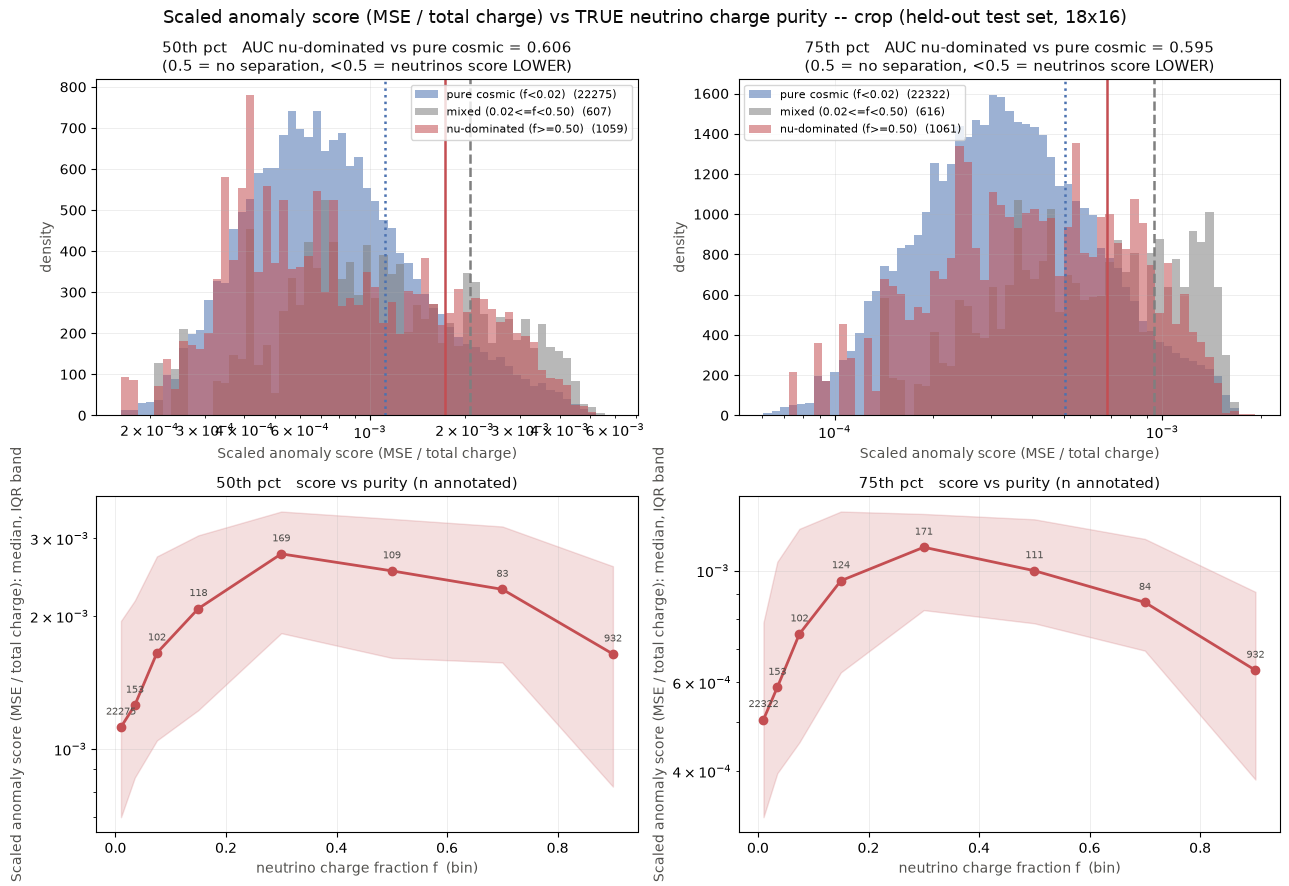


pct    | AUC raw (nu-dom vs cosmic)   | AUC scaled (nu-dom vs cosmic)
----------------------------------------------------------------------
50     | 0.344                        | 0.606                       
75     | 0.358                        | 0.595                       


In [12]:
# ---------- STEP 1: the same purity plots, with the SCALED anomaly score ----------
# The raw score is np.mean((X - rec)**2) over the WHOLE zero-padded frame, so it falls simply because
# a small cluster leaves most of the frame at zero (and zeros reconstruct to zeros).  The scaled score
# (paper 3.1.5, scaled_anomaly_score() in MBOONE_Training.py) divides the charge scale out:
#
#     scaled = raw MSE / total pixel charge
#
# Everything else -- classes, bins, trend bins, AUC definition -- is identical to the cell above, so
# the two figures are meant to be read side by side:
#   * inverted AUC SURVIVES scaling  -> the effect is not just brightness; it is topology or size.
#   * inverted AUC COLLAPSES to ~0.5 -> the previous result was the charge scale, nothing more.
# Reuses CL_PURITY / NU_FRAC / CL_EVAL from the cell above; adds "inten" and "scaled" to CL_PURITY
# so the STEP 2 cell can reuse them.  No re-scoring, no model needed.
FBINS = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.0001])
MIN_IN_BIN = 20

for pct in PCTS:
    z = CL_EVAL[pct]
    keep = ~np.isnan(NU_FRAC[z["raw_rows"]])
    d = CL_PURITY[pct]
    d["inten"] = z["inten"][keep].astype(np.float64)
    d["idx"] = z["idx"][keep]
    nz = d["inten"] > 0
    s = np.zeros(d["inten"].size, np.float64)
    s[nz] = d["score"][nz] / d["inten"][nz]
    d["scaled"] = s
    if int((~nz).sum()):
        print("%dth pct: %d test clusters have zero total charge -> excluded from log plots"
              % (pct, int((~nz).sum())))


def draw_purity_figure(key, sname):
    """The cell-above figure (score histograms by purity class + score-vs-f trend) for any score key."""
    fig, axes = plt.subplots(2, len(PCTS), figsize=(6.5 * len(PCTS), 9.0), squeeze=False)
    for col, pct in enumerate(PCTS):
        d = CL_PURITY[pct]
        good = d[key] > 0                      # log axes; drops zero-charge / zero-score clusters
        sc, f = d[key][good], d["f"][good]
        cls = classify(f)

        # -- row 0: score distribution per purity class --
        a = axes[0][col]
        bins = np.logspace(np.log10(float(sc.min())), np.log10(float(sc.max())), 60)
        for c in (0, 1, 2):
            v = sc[cls == c]
            if v.size == 0:
                continue
            a.hist(v, bins=bins, color=CLS_COL[c], alpha=0.55, density=True,
                   label="%s  (%d)" % (CLS_NAME[c], v.size))
            a.axvline(np.median(v), color=CLS_COL[c], ls=CLS_LS[c], lw=1.8)
        a.set_xscale("log"); a.grid(alpha=0.25, lw=0.6)
        a.set_xlabel("%s" % sname, color=INK2)
        a.set_ylabel("density", color=INK2); a.legend(fontsize=8)
        m = cls != 1
        auc = roc_curve_auc((cls[m] == 2).astype(int), sc[m])[2] if (cls == 2).any() else float("nan")
        a.set_title("%dth pct   AUC nu-dominated vs pure cosmic = %.3f\n(0.5 = no separation, "
                    "<0.5 = neutrinos score LOWER)" % (pct, auc), color=INK, fontsize=11)

        # -- row 1: median score vs purity, threshold-free --
        a = axes[1][col]
        ctr, med, q1, q3, ns = [], [], [], [], []
        for b0, b1 in zip(FBINS[:-1], FBINS[1:]):
            v = sc[(f >= b0) & (f < b1)]
            if v.size < MIN_IN_BIN:
                continue
            ctr.append(0.5 * (b0 + min(b1, 1.0))); ns.append(v.size)
            med.append(np.median(v)); q1.append(np.percentile(v, 25)); q3.append(np.percentile(v, 75))
        ctr, med, q1, q3 = map(np.array, (ctr, med, q1, q3))
        a.fill_between(ctr, q1, q3, color=NU_C, alpha=0.18)
        a.plot(ctr, med, color=NU_C, lw=2, marker="o", ms=6)
        for x, y, nn in zip(ctr, med, ns):
            a.annotate("%d" % nn, (x, y), textcoords="offset points", xytext=(0, 9),
                       ha="center", fontsize=7, color=INK2)
        a.set_yscale("log"); a.grid(alpha=0.25, lw=0.6)
        a.set_xlabel("neutrino charge fraction f  (bin)", color=INK2)
        a.set_ylabel("%s: median, IQR band" % sname, color=INK2)
        a.set_title("%dth pct   score vs purity (n annotated)" % pct, color=INK, fontsize=11)
    fig.suptitle("%s vs TRUE neutrino charge purity -- %s (held-out test set, %s)"
                 % (sname, DATASET, TILE_TAG), fontsize=13, color=INK)
    fig.tight_layout(); plt.show()
    return fig


draw_purity_figure("scaled", "Scaled anomaly score (MSE / total charge)")

# side-by-side AUC summary: raw vs scaled, on the identical class definition
print("\n%-6s | %-28s | %-28s" % ("pct", "AUC raw (nu-dom vs cosmic)", "AUC scaled (nu-dom vs cosmic)"))
print("-" * 70)
for pct in PCTS:
    d = CL_PURITY[pct]
    row = []
    for key in ("score", "scaled"):
        good = d[key] > 0
        cls = classify(d["f"][good]); m = cls != 1
        row.append(roc_curve_auc((cls[m] == 2).astype(int), d[key][good][m])[2])
    print("%-6d | %-28.3f | %-28.3f" % (pct, row[0], row[1]))

Spearman rank correlation of the score with size/brightness proxies
(|rho| near 1 = the score is essentially THAT variable, not topology)

pct   | score   | vs inten  | vs fill   | vs area  
----------------------------------------------------
50    | raw     | 0.831     | 0.820     | 0.580    
50    | scaled  | 0.111     | 0.119     | 0.079    
75    | raw     | 0.928     | 0.919     | 0.827    
75    | scaled  | 0.358     | 0.360     | 0.358    


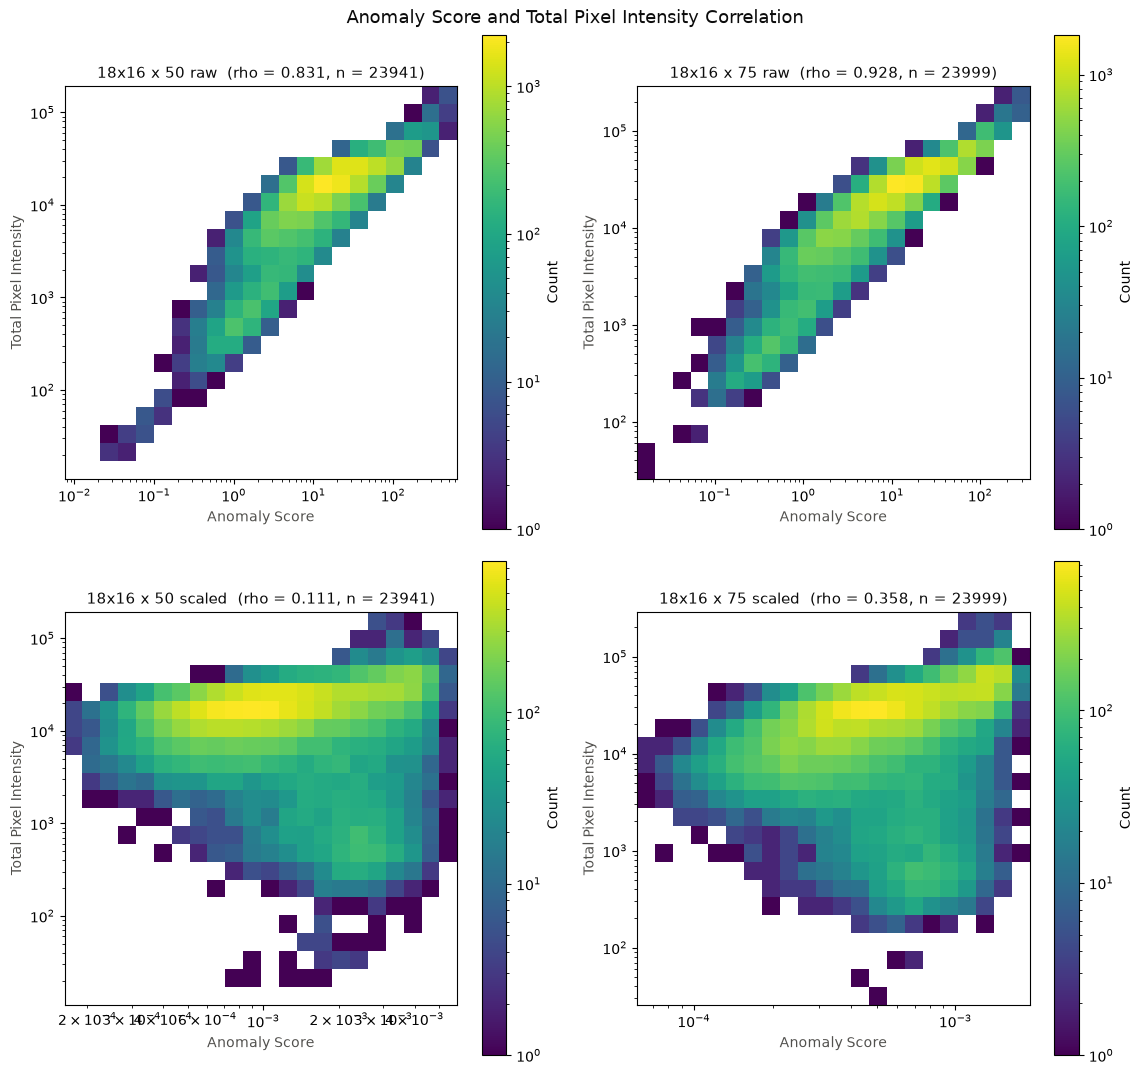

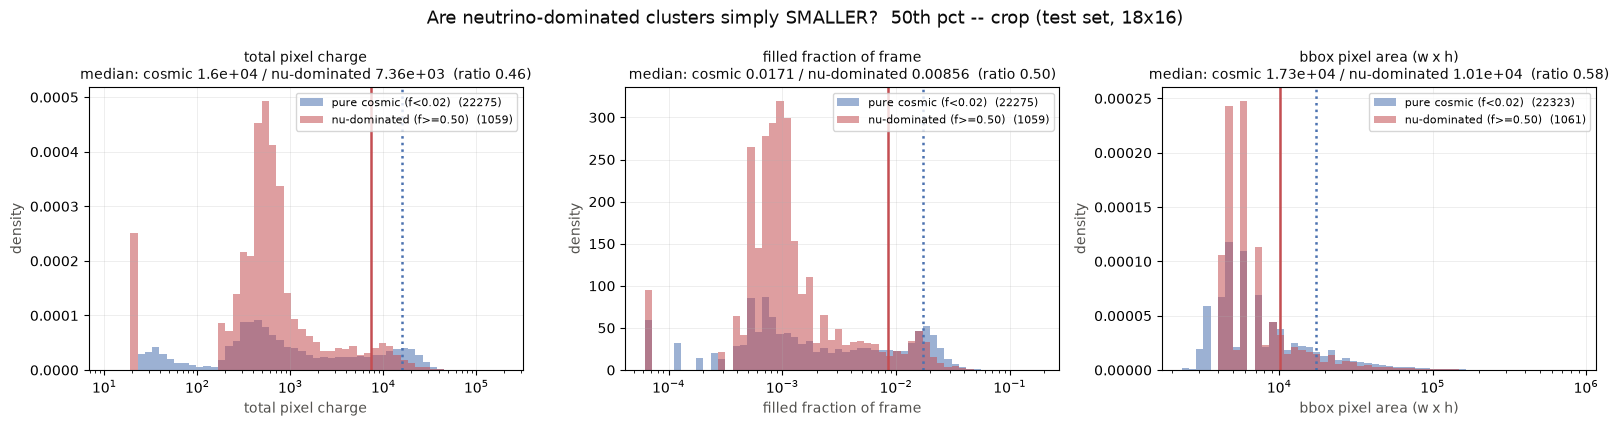


If the ratios above are well below 1 AND |rho| vs fill/inten is large, then the sub-0.5 AUC is
a size effect: the score is reporting 'how much of the frame is lit', not cluster topology.


In [21]:
# ---------- STEP 2: is the inverted AUC actually a SIZE / BRIGHTNESS measurement? ----------
# STEP 1 asked whether dividing by charge changes the answer.  This cell asks the blunter question:
# how much of the anomaly score is explained by three quantities that have nothing to do with
# neutrinos, and are those quantities themselves different between the two purity classes?
#
#   inten = total pixel charge in the padded frame   (brightness)
#   fill  = fraction of frame pixels that are non-zero (how much of the frame the cluster occupies)
#   area  = bbox pixel area, image_width_px * image_height_px (physical cluster size, pre-pad)
#
# The logic: MSE is averaged over the whole padded frame, so a cluster that fills 5% of the frame is
# ~95% exactly-reconstructed zeros.  If (a) the score tracks fill/inten tightly AND (b) nu-dominated
# clusters are systematically smaller than cosmic ones, then "neutrinos look less anomalous" is a size
# measurement wearing a neutrino costume, and the AUC below 0.5 says nothing about topology.
# Needs STEP 1 above (CL_PURITY carries inten / scaled / idx).  Reads pixels but never the model.
from matplotlib.colors import LogNorm

FILL_CHUNK = 512


def _rank(a):
    """Average ranks (ties shared), so Spearman is well defined on the many equal-valued scores."""
    a = np.asarray(a, float)
    order = np.argsort(a, kind="mergesort")
    r = np.empty(a.size, float)
    r[order] = np.arange(a.size, dtype=float)
    s = a[order]
    i = 0
    while i < s.size:
        j = i
        while j + 1 < s.size and s[j + 1] == s[i]:
            j += 1
        if j > i:
            r[order[i:j + 1]] = 0.5 * (i + j)
        i = j + 1
    return r


def spearman(a, b):
    ra, rb = _rank(a), _rank(b)
    ra = ra - ra.mean(); rb = rb - rb.mean()
    den = np.sqrt(float((ra * ra).sum()) * float((rb * rb).sum()))
    return float((ra * rb).sum() / den) if den > 0 else float("nan")


def cluster_fill_area(pct):
    """Per test cluster: non-zero pixel FRACTION of the padded frame, and the raw bbox pixel area."""
    cache = CIMG / ("cluster_fill_%s%d_%s.npz" % (VTAG, pct, TILE_TAG))
    if cache.exists():
        return dict(np.load(cache))
    with h5py.File(str(padded_path(pct)), "r") as fp:
        imgs = fp["images"]
        te = test_rows(imgs.shape[0])
        npix = int(imgs.shape[1] * imgs.shape[2])
        nnz = []
        for s in range(0, len(te), FILL_CHUNK):
            X = imgs[te[s:s + FILL_CHUNK]]
            nnz.append((X != 0).sum(axis=(1, 2)))
        w = fp["metadata/image_width_px"][:][te].astype(np.float64)
        h = fp["metadata/image_height_px"][:][te].astype(np.float64)
    out = dict(fill=np.concatenate(nnz).astype(np.float64) / npix, area=w * h,
               idx=te, npix=np.array(npix))
    np.savez(cache, **out)
    print("cached %s" % cache.name)
    return out


for pct in PCTS:
    d = CL_PURITY[pct]
    fa = cluster_fill_area(pct)
    pos = np.searchsorted(fa["idx"], d["idx"])        # CL_PURITY rows are a subset of test_rows
    assert np.array_equal(fa["idx"][pos], d["idx"]), "fill/area rows do not line up with CL_PURITY"
    d["fill"] = fa["fill"][pos]
    d["area"] = fa["area"][pos]
    d["npix"] = int(fa["npix"])

# ---- how much of each score is just size / brightness? ----
print("Spearman rank correlation of the score with size/brightness proxies")
print("(|rho| near 1 = the score is essentially THAT variable, not topology)\n")
print("%-5s | %-7s | %-9s | %-9s | %-9s" % ("pct", "score", "vs inten", "vs fill", "vs area"))
print("-" * 52)
for pct in PCTS:
    d = CL_PURITY[pct]
    for key, nm in (("score", "raw"), ("scaled", "scaled")):
        g = d[key] > 0
        print("%-5d | %-7s | %-9.3f | %-9.3f | %-9.3f"
              % (pct, nm, spearman(d[key][g], d["inten"][g]), spearman(d[key][g], d["fill"][g]),
                 spearman(d[key][g], d["area"][g])))

# ========== FIGURE 1 (FIREFLY Fig. 12 style): anomaly score vs total pixel intensity ==========
# Same conventions as the FIREFLY paper's "Total Pixel Intensity Correlation": score on x, total
# pixel intensity on y, both log, a square 2-D COUNT histogram in viridis with a log colour scale
# and empty bins left white.  Read it as: a tight narrow diagonal means the anomaly score is very
# nearly a restatement of how much charge is in the frame (FIREFLY's own caption reads the positive
# trend as "more ionization -> more possible reconstruction loss"); a broad cloud means charge is
# only one of several drivers and topology still has room to matter.
# Rows are raw vs scaled score: if the raw row is a tight diagonal and the scaled row is a
# structureless blob, the division by charge did its job.
SCORE_FLOOR = 0.0        # FIREFLY excludes anomaly scores < 1; keep 0 here so nothing is hidden
NBINS_2D = 22            # per axis, log-spaced -- roughly the chunky bin size of the paper figure
SHOW_TREND = True        # median-intensity-per-score-decile line (not in the paper; drop if unwanted)

fig, axes = plt.subplots(2, len(PCTS), figsize=(5.8 * len(PCTS), 11.0), squeeze=False)
for col, pct in enumerate(PCTS):
    d = CL_PURITY[pct]
    for row, (key, nm) in enumerate((("score", "Raw anomaly score"),
                                     ("scaled", "Scaled anomaly score"))):
        a = axes[row][col]
        g = (d[key] > SCORE_FLOOR) & (d[key] > 0) & (d["inten"] > 0)
        x, y = d[key][g], d["inten"][g]              # x = score, y = intensity (paper's orientation)
        xb = np.logspace(np.log10(x.min()), np.log10(x.max()), NBINS_2D + 1)
        yb = np.logspace(np.log10(y.min()), np.log10(y.max()), NBINS_2D + 1)
        hh = a.hist2d(x, y, bins=[xb, yb], cmap="viridis", norm=LogNorm(), cmin=1)
        fig.colorbar(hh[3], ax=a, label="Count")
        
        a.set_xscale("log"); a.set_yscale("log"); a.set_box_aspect(1)
        a.set_xlabel("Anomaly Score", color=INK2)
        a.set_ylabel("Total Pixel Intensity", color=INK2)
        a.set_title("%s x %s %s  (rho = %.3f, n = %d)"
                    % (TILE_TAG, pct, nm.split()[0].lower(), spearman(x, y), x.size),
                    color=INK, fontsize=11)
fig.suptitle("Anomaly Score and Total Pixel Intensity Correlation", fontsize=13, color=INK)
fig.tight_layout(); plt.show()

# ================= FIGURE 2: are the two purity classes the same SIZE to begin with? =================
pct0 = PCTS[0]
d0 = CL_PURITY[pct0]
cls0 = classify(d0["f"])
VARS = [("inten", "total pixel charge"), ("fill", "filled fraction of frame"),
        ("area", "bbox pixel area (w x h)")]

fig, axes = plt.subplots(1, len(VARS), figsize=(5.4 * len(VARS), 4.3))
for a, (key, nm) in zip(axes, VARS):
    v = d0[key]
    g = v > 0
    bins = np.logspace(np.log10(float(v[g].min())), np.log10(float(v[g].max())), 55)
    for c in (0, 2):                        # pure cosmic vs nu-dominated; the mixed band is the confound
        m = g & (cls0 == c)
        if not m.any():
            continue
        a.hist(v[m], bins=bins, color=CLS_COL[c], alpha=0.55, density=True,
               label="%s  (%d)" % (CLS_NAME[c], int(m.sum())))
        a.axvline(np.median(v[m]), color=CLS_COL[c], ls=CLS_LS[c], lw=1.8)
    a.set_xscale("log"); a.grid(alpha=0.25, lw=0.6)
    a.set_xlabel(nm, color=INK2); a.set_ylabel("density", color=INK2)
    a.legend(fontsize=8)
    med_c = np.median(v[g & (cls0 == 0)]); med_n = np.median(v[g & (cls0 == 2)])
    a.set_title("%s\nmedian: cosmic %.3g / nu-dominated %.3g  (ratio %.2f)"
                % (nm, med_c, med_n, (med_n / med_c) if med_c else np.nan), color=INK, fontsize=10)
fig.suptitle("Are neutrino-dominated clusters simply SMALLER?  %dth pct -- %s (test set, %s)"
             % (pct0, DATASET, TILE_TAG), fontsize=13, color=INK)
fig.tight_layout(); plt.show()

print("\nIf the ratios above are well below 1 AND |rho| vs fill/inten is large, then the sub-0.5 AUC is")
print("a size effect: the score is reporting 'how much of the frame is lit', not cluster topology.")

### Input v.s. Reconstruction

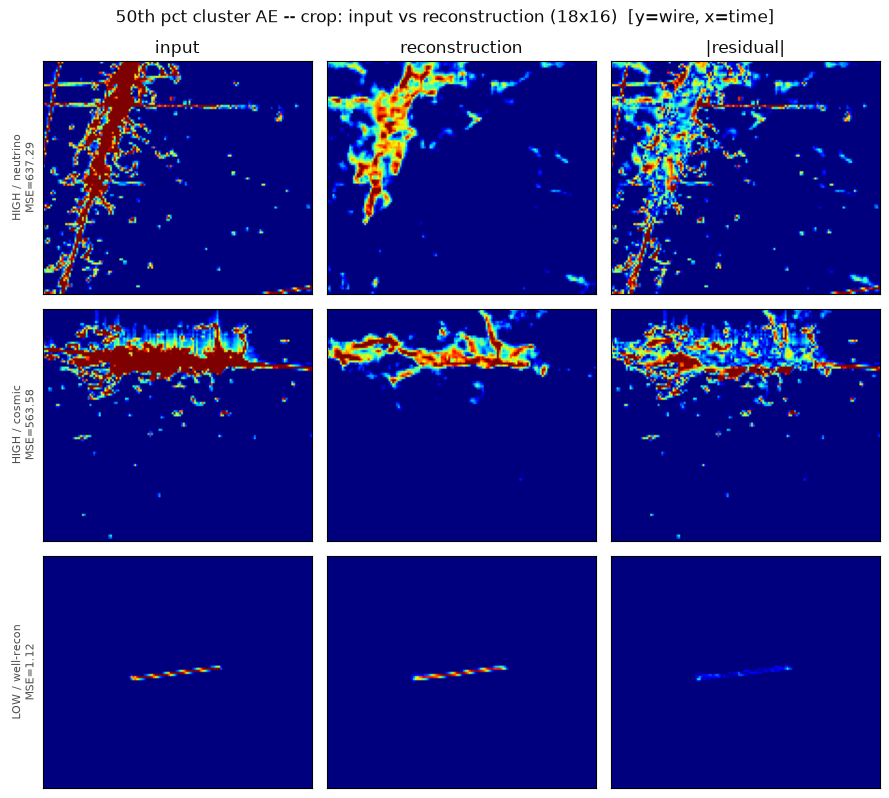

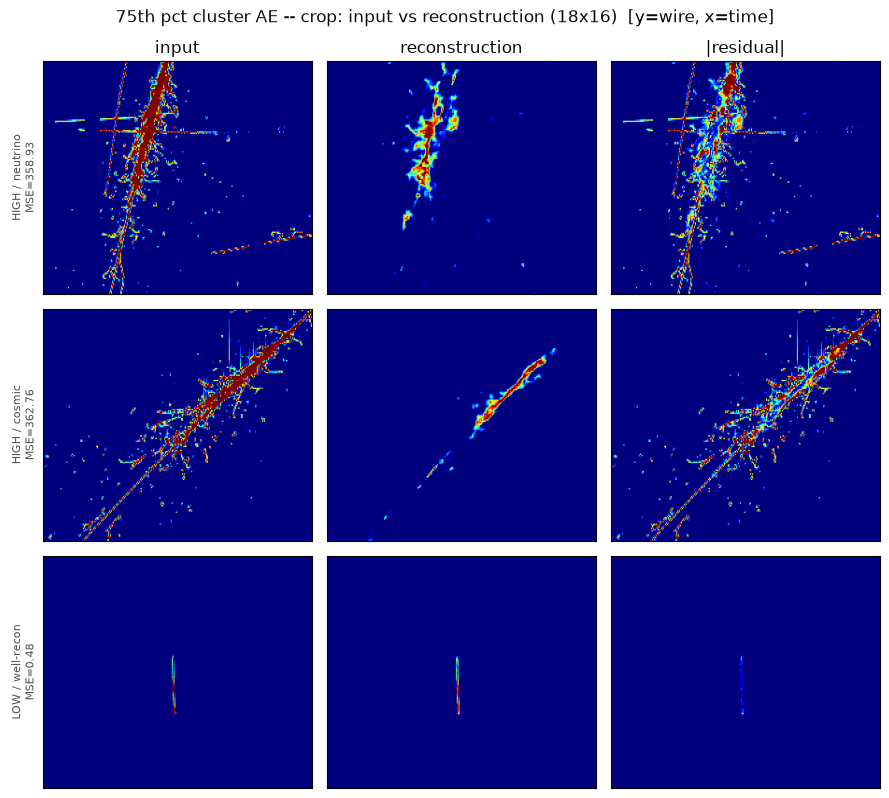

In [20]:
# Input vs reconstruction for representative TEST clusters of the chosen DATASET (config
# cell): highest-anomaly neutrino, highest-anomaly cosmic, and a low-anomaly (cleanly
# reconstructed) cluster -- shown as input | reconstruction | |residual| (the residual IS
# the anomaly score).  Uses cluster_model + CL_EVAL from the Anomaly cell above.
picks_spec = [("HIGH / neutrino", True, True),      # (label, neutrino? , want-high-score?)
              ("HIGH / cosmic", False, True),
              ("LOW / well-recon", None, False)]

for pct in PCTS:
    z = CL_EVAL[pct]
    raw, idx, inten = z["raw"], z["idx"], z["inten"]
    isnu = z["is_nu"].astype(bool)
    real = inten > np.percentile(inten, 20)          # skip near-empty crops

    def pick(is_nu_flag, want_high):
        m = real if is_nu_flag is None else real & (isnu if is_nu_flag else ~isnu)
        if not m.any():
            m = real
        j = np.argmax(raw[m]) if want_high else np.argmin(raw[m])
        return int(idx[np.where(m)[0][j]])

    picks = [(pick(a, b), tag) for (tag, a, b) in picks_spec]
    model = cluster_model(pct)
    f = h5py.File(str(padded_path(pct)), "r")
    imgs = {r: f["images"][r] for r in sorted(set(p for p, _ in picks))}
    f.close()

    fig, axes = plt.subplots(len(picks), 3, figsize=(9, 2.7 * len(picks)), squeeze=False)
    for r, (row, tag) in enumerate(picks):
        X = imgs[row][None, ..., None].astype("float32")
        rec = model.predict(X, batch_size=1, verbose=0)[0, :, :, 0]
        inp = X[0, :, :, 0]
        vmax = max(1.0, float(inp.max()))
        for c, (im, ttl) in enumerate([(inp, "input"), (rec, "reconstruction"), (np.abs(inp - rec), "|residual|")]):
            axes[r, c].imshow(im.T, origin="lower", cmap="jet", vmin=0, vmax=vmax, aspect="auto")
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
            if r == 0:
                axes[r, c].set_title(ttl, color=INK)
        axes[r, 0].set_ylabel("%s\nMSE=%.2f" % (tag, float(np.mean((inp - rec) ** 2))),
                              fontsize=8, color=INK2)
    fig.suptitle("%dth pct cluster AE -- %s: input vs reconstruction (18x16)  [y=wire, x=time]" % (pct, DATASET),
                 fontsize=12, color=INK)
    fig.tight_layout()
    plt.show()
    keras.backend.clear_session()